# 🌾 Seasonal Agriculture Performance Analysis

## Major Project

This notebook analyzes agricultural performance across seasons and investigates:
- seasonal performance, yield and production
- environmental conditions
- resource usage and irrigation
- crop and regional differences
- water efficiency
- disease/pest risk
- economic outcomes
- relationships between variables
- unusual observations
- statistical significance
- evidence-based recommendations

All numerical findings are calculated automatically from the supplied dataset when the notebook is run.

## 1. Problem Statement

Agricultural activities are influenced by seasonal variations in environmental conditions, farming practices, resource availability and market conditions. This project investigates how agricultural performance changes across seasons and identifies meaningful patterns, trends, relationships and variations in the available data.

## 2. Key Analytical Questions

1. How does agricultural performance vary across seasons?
2. What major seasonal patterns can be observed?
3. Which characteristics change between seasons?
4. What differences exist between agricultural activities in different seasons?
5. Are there variations in resource usage across seasons?
6. Are environmental conditions related to agricultural performance?
7. How do economic outcomes vary across seasons?
8. Are seasonal patterns consistent across crops and regions?
9. Are there unusual or unexpected seasonal patterns?
10. What insights can be derived from the observed seasonal differences?
11. How can the findings support better seasonal agricultural planning?

## 3. Import Libraries

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from sklearn.preprocessing import MinMaxScaler

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
sns.set_theme(style="whitegrid")

## 4. Load Dataset

In [ ]:
DATA_FILE = "/content/seasonal_agriculture_performance_dataset.csv"
df = pd.read_csv(DATA_FILE)

print(f"Dataset loaded successfully.")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]:,}")

Dataset loaded successfully.
Rows: 4,000
Columns: 28


## 5. Dataset Overview

In [ ]:
display(df.head())

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.40,24.30,69.10,5.80,7.14,32.80,75.80,61.30,91.00,Drip,242.70,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.49,55.30
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.40,25.70,78.40,5.10,5.20,32.00,82.10,35.40,121.80,Flood,271.40,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.40,49.90
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.60,23.90,56.40,10.30,5.82,8.10,118.50,51.50,117.90,Drip,162.60,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.98,33.70
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.20,29.70,65.20,6.30,5.98,23.70,138.60,55.60,115.50,Rainfed,182.20,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.16,50.60
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.60,34.10,55.20,6.50,6.90,29.30,124.10,69.00,121.40,Flood,244.90,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.83,32.30


In [ ]:
df.sample(5, random_state=42)

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
555,SF10556,Andhra Pradesh,Nashik,Chilli,Rabi,7.94,456.80,25.30,47.70,7.60,7.10,12.90,108.00,75.80,96.50,Flood,228.20,8.51,0.87,NaN,15.64,92892,619157,1452831,833674,6146,2.54,34.40
3491,SF13492,Punjab,Warangal,Wheat,Kharif,12.44,601.90,27.20,60.20,8.30,7.66,24.30,97.80,36.70,96.00,Drip,65.90,6.88,0.77,0.94,11.69,23614,680562,276048,-404514,5818,2.01,31.80
527,SF10528,Maharashtra,Indore,Cotton,Kharif,6.35,"1,213.70",26.30,73.60,7.10,6.33,30.40,149.30,41.80,98.80,Drip,143.00,5.63,0.69,1.17,7.43,69828,441813,518822,77009,4491,1.65,52.70
3925,SF13926,Madhya Pradesh,Nashik,Wheat,Rabi,12.52,374.00,17.90,59.70,9.40,7.57,24.50,118.60,77.50,128.70,Rainfed,116.40,5.14,0.71,0.88,11.02,26649,744970,293672,-451298,3347,3.29,29.80
2989,SF12990,Gujarat,Rajkot,Chilli,Rabi,13.98,197.80,19.00,55.80,9.20,7.31,18.90,45.80,79.90,126.70,Flood,242.80,4.87,0.95,1.07,14.96,108549,994707,1623893,629186,10975,1.36,39.60


In [ ]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Shape: (4000, 28)

Columns:
['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [ ]:
display(df.describe(include='all').T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Farm_ID,4000,4000,SF13984,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
State,4000,8,Andhra Pradesh,529,NaN,NaN,NaN,NaN,NaN,NaN,NaN
District,4000,10,Ludhiana,427,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Crop,4000,8,Rice,690,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Season,4000,3,Kharif,1779,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Farm_Area_Hectares,"4,000.00",NaN,NaN,NaN,7.89,4.22,0.50,4.26,7.89,11.65,15.00
Rainfall_mm,"3,952.00",NaN,NaN,NaN,601.15,288.93,80.00,370.20,582.00,834.95,"1,395.20"
Avg_Temperature_C,"4,000.00",NaN,NaN,NaN,26.82,3.82,16.20,23.90,26.90,29.60,39.70
Humidity_pct,"4,000.00",NaN,NaN,NaN,63.21,11.96,25.00,54.77,63.00,71.90,95.00
Sunlight_Hours_Day,"4,000.00",NaN,NaN,NaN,7.32,1.12,3.50,6.60,7.30,8.10,11.00


## 6. Data Quality Assessment

In [ ]:
quality = pd.DataFrame({
    "Data_Type": df.dtypes.astype(str),
    "Missing_Count": df.isna().sum(),
    "Missing_%": (df.isna().mean() * 100).round(2),
    "Unique_Values": df.nunique()
}).sort_values("Missing_Count", ascending=False)

display(quality)
print("Duplicate rows:", df.duplicated().sum())

,Data_Type,Missing_Count,Missing_%,Unique_Values
Rainfall_mm,float64,48,1.20,3256
Soil_Moisture_pct,float64,40,1.00,343
Yield_Tonnes_Ha,float64,32,0.80,738
Farm_ID,object,0,0.00,4000
Crop,object,0,0.00,8
District,object,0,0.00,10
Farm_Area_Hectares,float64,0,0.00,1370
Season,object,0,0.00,3
Avg_Temperature_C,float64,0,0.00,204
Humidity_pct,float64,0,0.00,573


Duplicate rows: 0


In [ ]:
categorical_columns = df.select_dtypes(include=["object", "category"]).columns.tolist()

for col in categorical_columns:
    print(f"\n--- {col} ---")
    print(df[col].value_counts(dropna=False))


--- Farm_ID ---
Farm_ID
SF13984    1
SF13983    1
SF13982    1
SF13981    1
SF13980    1
          ..
SF10005    1
SF10004    1
SF10003    1
SF10002    1
SF10001    1
Name: count, Length: 4000, dtype: int64

--- State ---
State
Andhra Pradesh    529
Telangana         516
Maharashtra       512
Madhya Pradesh    497
Karnataka         489
Gujarat           488
Tamil Nadu        485
Punjab            484
Name: count, dtype: int64

--- District ---
District
Ludhiana    427
Warangal    422
Nalgonda    415
Erode       403
Rajkot      401
Krishna     393
Indore      392
Guntur      390
Raichur     386
Nashik      371
Name: count, dtype: int64

--- Crop ---
Crop
Rice         690
Wheat        614
Maize        551
Cotton       508
Pulses       496
Groundnut    424
Chilli       412
Sugarcane    305
Name: count, dtype: int64

--- Season ---
Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64

--- Irrigation_Method ---
Irrigation_Method
Flood        1310
Rainfed      1041


## 7. Data Cleaning and Preparation

Duplicate rows are removed if present. Numerical missing values are filled with the median, while categorical missing values are filled with the mode.

In [ ]:
df = df.drop_duplicates().copy()

numeric_columns = df.select_dtypes(include=np.number).columns.tolist()
categorical_columns = df.select_dtypes(include=["object", "category"]).columns.tolist()

for col in numeric_columns:
    if df[col].isna().any():
        df[col] = df[col].fillna(df[col].median())

for col in categorical_columns:
    if df[col].isna().any():
        df[col] = df[col].fillna(df[col].mode()[0])

print("Remaining missing values:", int(df.isna().sum().sum()))
print("Remaining duplicate rows:", int(df.duplicated().sum()))

Remaining missing values: 0
Remaining duplicate rows: 0


In [ ]:
df.dtypes

,0
Farm_ID,object
State,object
District,object
Crop,object
Season,object
Farm_Area_Hectares,float64
Rainfall_mm,float64
Avg_Temperature_C,float64
Humidity_pct,float64
Sunlight_Hours_Day,float64


In [ ]:
categorical_columns=df.select_dtypes(include=["object","category"]).columns.tolist()
for col in categorical_columns:
    print(df[col].nunique(),"unique values")
    print(df[col].dropna().unique()[:20])

4000 unique values
['SF10001' 'SF10002' 'SF10003' 'SF10004' 'SF10005' 'SF10006' 'SF10007'
 'SF10008' 'SF10009' 'SF10010' 'SF10011' 'SF10012' 'SF10013' 'SF10014'
 'SF10015' 'SF10016' 'SF10017' 'SF10018' 'SF10019' 'SF10020']
8 unique values
['Andhra Pradesh' 'Maharashtra' 'Telangana' 'Karnataka' 'Gujarat'
 'Tamil Nadu' 'Punjab' 'Madhya Pradesh']
10 unique values
['Rajkot' 'Nalgonda' 'Warangal' 'Indore' 'Ludhiana' 'Raichur' 'Guntur'
 'Krishna' 'Nashik' 'Erode']
8 unique values
['Wheat' 'Maize' 'Pulses' 'Rice' 'Cotton' 'Chilli' 'Groundnut' 'Sugarcane']
3 unique values
['Kharif' 'Rabi' 'Zaid']
4 unique values
['Drip' 'Flood' 'Rainfed' 'Sprinkler']


In [ ]:
df.isnull().sum().sort_values(ascending=False).head(20)

,0
Farm_ID,0
State,0
District,0
Crop,0
Season,0
Farm_Area_Hectares,0
Rainfall_mm,0
Avg_Temperature_C,0
Humidity_pct,0
Sunlight_Hours_Day,0


## 8. Feature Engineering

Additional per-hectare and margin measures are created to support comparisons across farms of different sizes.

In [ ]:
def safe_divide(a, b):
    return np.where(b != 0, a / b, np.nan)

if {"Profit_INR", "Revenue_INR"}.issubset(df.columns):
    df["Profit_Margin_pct"] = safe_divide(df["Profit_INR"], df["Revenue_INR"]) * 100

if {"Total_Cost_INR", "Farm_Area_Hectares"}.issubset(df.columns):
    df["Cost_per_Hectare"] = safe_divide(df["Total_Cost_INR"], df["Farm_Area_Hectares"])

if {"Revenue_INR", "Farm_Area_Hectares"}.issubset(df.columns):
    df["Revenue_per_Hectare"] = safe_divide(df["Revenue_INR"], df["Farm_Area_Hectares"])

if {"Profit_INR", "Farm_Area_Hectares"}.issubset(df.columns):
    df["Profit_per_Hectare"] = safe_divide(df["Profit_INR"], df["Farm_Area_Hectares"])

if {"Production_Tonnes", "Farm_Area_Hectares"}.issubset(df.columns):
    df["Production_per_Hectare"] = safe_divide(df["Production_Tonnes"], df["Farm_Area_Hectares"])

display(df.head())

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct,Profit_Margin_pct,Cost_per_Hectare,Revenue_per_Hectare,Profit_per_Hectare,Production_per_Hectare
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.40,24.30,69.10,5.80,7.14,32.80,75.80,61.30,91.00,Drip,242.70,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.49,55.30,-38.47,"80,494.34","58,132.08","-22,362.26",2.45
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.40,25.70,78.40,5.10,5.20,32.00,82.10,35.40,121.80,Flood,271.40,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.40,49.90,"-1,118.66","75,398.32","6,186.98","-69,211.33",0.30
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.60,23.90,56.40,10.30,5.82,8.10,118.50,51.50,117.90,Drip,162.60,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.98,33.70,-65.49,"64,858.02","39,190.53","-25,667.49",0.52
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.20,29.70,65.20,6.30,5.98,23.70,138.60,55.60,115.50,Rainfed,182.20,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.16,50.60,-47.68,"65,876.44","44,608.89","-21,267.56",1.84
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.60,34.10,55.20,6.50,6.90,29.30,124.10,69.00,121.40,Flood,244.90,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.83,32.30,-74.56,"80,275.30","45,987.41","-34,287.89",2.21


## 9. Overall Agricultural Performance

In [ ]:
kpis = {
    "Total farms": df["Farm_ID"].nunique() if "Farm_ID" in df else len(df),
    "Total farm area (hectares)": df["Farm_Area_Hectares"].sum(),
    "Total production (tonnes)": df["Production_Tonnes"].sum(),
    "Average yield (tonnes/ha)": df["Yield_Tonnes_Ha"].mean(),
    "Total revenue (INR)": df["Revenue_INR"].sum(),
    "Total cost (INR)": df["Total_Cost_INR"].sum(),
    "Total profit (INR)": df["Profit_INR"].sum(),
    "Average water efficiency": df["Water_Efficiency_t_per_1000m3"].mean()
}
display(pd.DataFrame({"Metric": list(kpis.keys()), "Value": list(kpis.values())}))

,Metric,Value
0,Total farms,"4,000.00"
1,Total farm area (hectares),"31,553.06"
2,Total production (tonnes),"172,984.84"
3,Average yield (tonnes/ha),5.24
4,Total revenue (INR),"2,551,440,192.00"
5,Total cost (INR),"2,105,214,332.00"
6,Total profit (INR),"446,225,860.00"
7,Average water efficiency,5.39


## 10. Seasonal Distribution

,Farm Records
Season,
Kharif,1779
Rabi,1627
Zaid,594


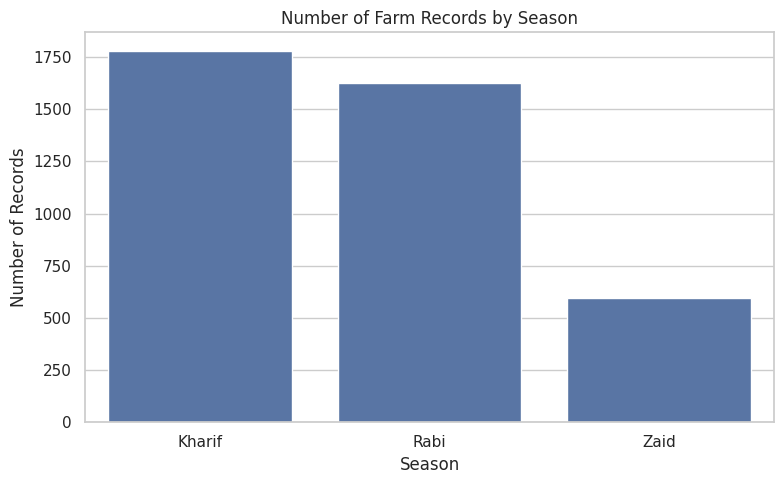

In [ ]:
season_counts = df["Season"].value_counts()

display(season_counts.to_frame("Farm Records"))

plt.figure(figsize=(8,5))
sns.countplot(data=df, x="Season", order=season_counts.index)
plt.title("Number of Farm Records by Season")
plt.xlabel("Season")
plt.ylabel("Number of Records")
plt.tight_layout()
plt.show()

## 11. Seasonal Agricultural Performance

In [ ]:
season_performance = df.groupby("Season").agg(
    Records=("Season", "size"),
    Avg_Area_Ha=("Farm_Area_Hectares", "mean"),
    Avg_Yield=("Yield_Tonnes_Ha", "mean"),
    Avg_Production=("Production_Tonnes", "mean"),
    Avg_Revenue=("Revenue_INR", "mean"),
    Avg_Cost=("Total_Cost_INR", "mean"),
    Avg_Profit=("Profit_INR", "mean"),
    Avg_Water_Used=("Water_Used_m3", "mean"),
    Avg_Water_Efficiency=("Water_Efficiency_t_per_1000m3", "mean"),
    Avg_Disease_Risk=("Disease_Pest_Risk_pct", "mean")
).round(2)

display(season_performance)

,Records,Avg_Area_Ha,Avg_Yield,Avg_Production,Avg_Revenue,Avg_Cost,Avg_Profit,Avg_Water_Used,Avg_Water_Efficiency,Avg_Disease_Risk
Season,,,,,,,,,,
Kharif,1779,7.94,5.63,46.31,"710,719.06","531,804.41","178,914.65","6,102.20",5.89,54.47
Rabi,1627,7.75,5.04,41.49,"601,526.05","513,836.58","87,689.47","5,846.99",5.19,40.48
Zaid,594,8.09,4.64,38.89,"519,171.90","543,976.73","-24,804.82","6,419.89",4.41,38.22


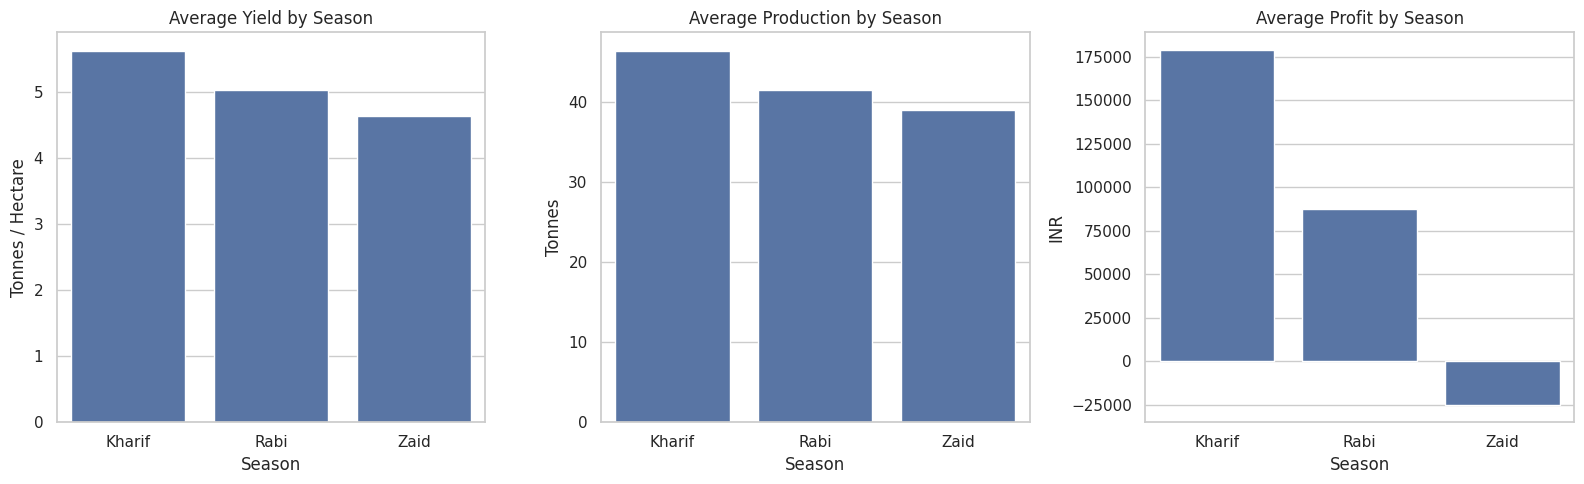

In [ ]:
fig, axes = plt.subplots(1,3, figsize=(16,5))

sns.barplot(data=df, x="Season", y="Yield_Tonnes_Ha", estimator="mean", errorbar=None, ax=axes[0])
axes[0].set_title("Average Yield by Season")
axes[0].set_ylabel("Tonnes / Hectare")

sns.barplot(data=df, x="Season", y="Production_Tonnes", estimator="mean", errorbar=None, ax=axes[1])
axes[1].set_title("Average Production by Season")
axes[1].set_ylabel("Tonnes")

sns.barplot(data=df, x="Season", y="Profit_INR", estimator="mean", errorbar=None, ax=axes[2])
axes[2].set_title("Average Profit by Season")
axes[2].set_ylabel("INR")

plt.tight_layout()
plt.show()

## 12. Seasonal Yield Distribution

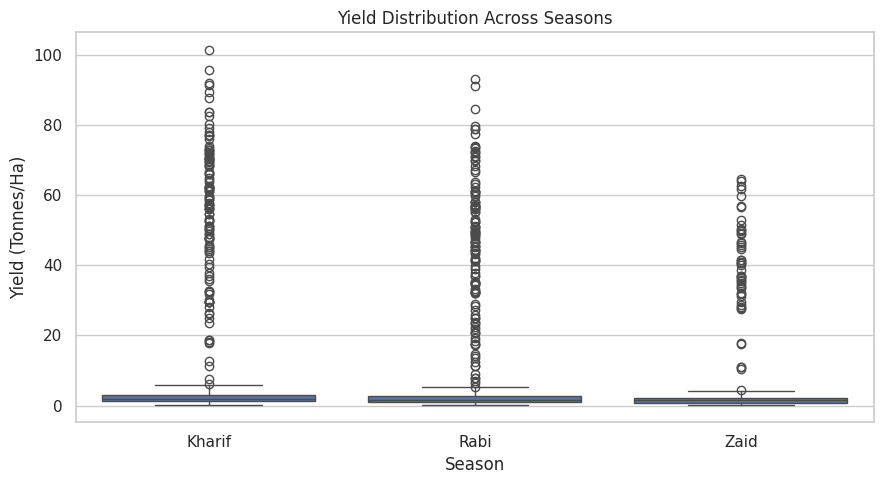

In [ ]:
plt.figure(figsize=(9,5))
sns.boxplot(data=df, x="Season", y="Yield_Tonnes_Ha")
plt.title("Yield Distribution Across Seasons")
plt.xlabel("Season")
plt.ylabel("Yield (Tonnes/Ha)")
plt.tight_layout()
plt.show()

## 13. Seasonal Economic Performance

,Revenue_INR,Total_Cost_INR,Profit_INR
Season,,,
Kharif,"710,719.06","531,804.41","178,914.65"
Rabi,"601,526.05","513,836.58","87,689.47"
Zaid,"519,171.90","543,976.73","-24,804.82"


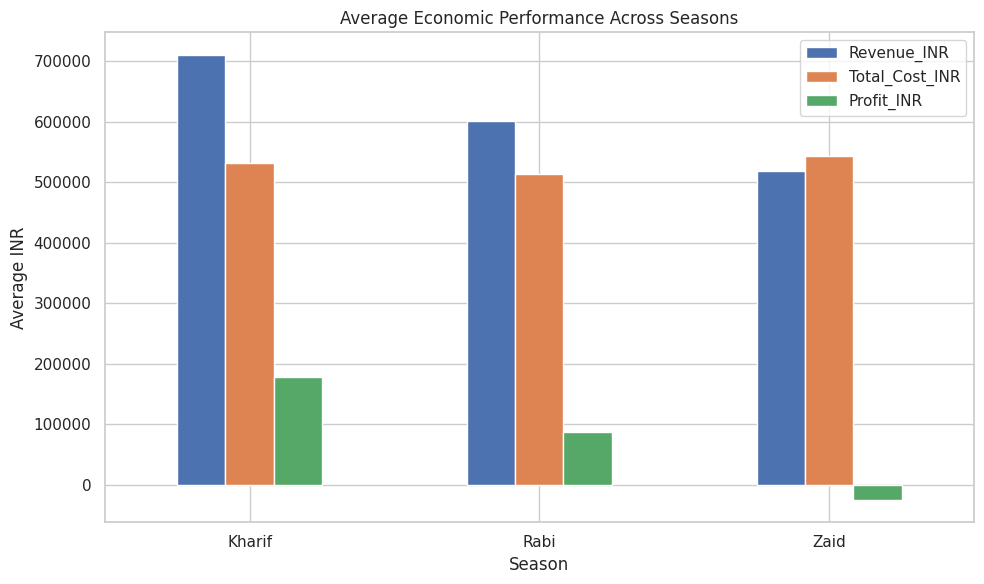

In [ ]:
economic_season = df.groupby("Season")[["Revenue_INR","Total_Cost_INR","Profit_INR"]].mean().round(2)
display(economic_season)

economic_season.plot(kind="bar", figsize=(10,6))
plt.title("Average Economic Performance Across Seasons")
plt.xlabel("Season")
plt.ylabel("Average INR")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 14. Environmental Conditions Across Seasons

In [ ]:
environmental_variables = [
    "Rainfall_mm", "Avg_Temperature_C", "Humidity_pct",
    "Sunlight_Hours_Day", "Soil_pH", "Soil_Moisture_pct"
]

environmental_season = df.groupby("Season")[environmental_variables].mean().round(2)
display(environmental_season)

,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct
Season,,,,,,
Kharif,849.20,28.45,71.81,6.79,6.73,31.15
Rabi,437.62,23.49,57.89,7.59,6.67,24.07
Zaid,304.65,31.04,52.01,8.18,6.69,19.28


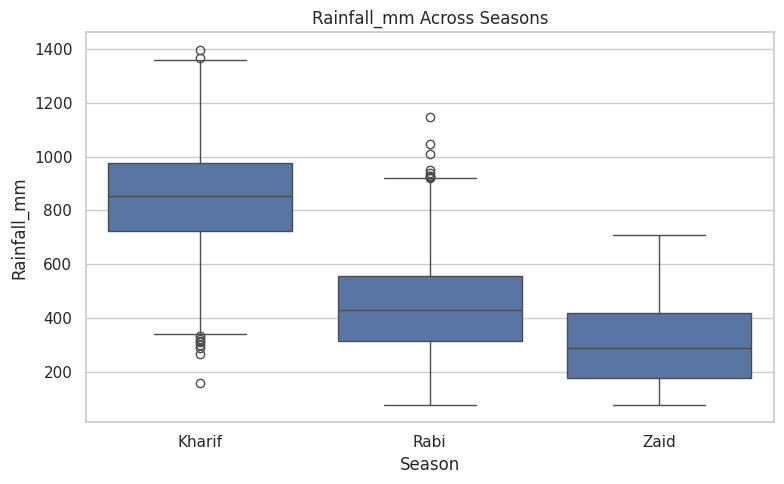

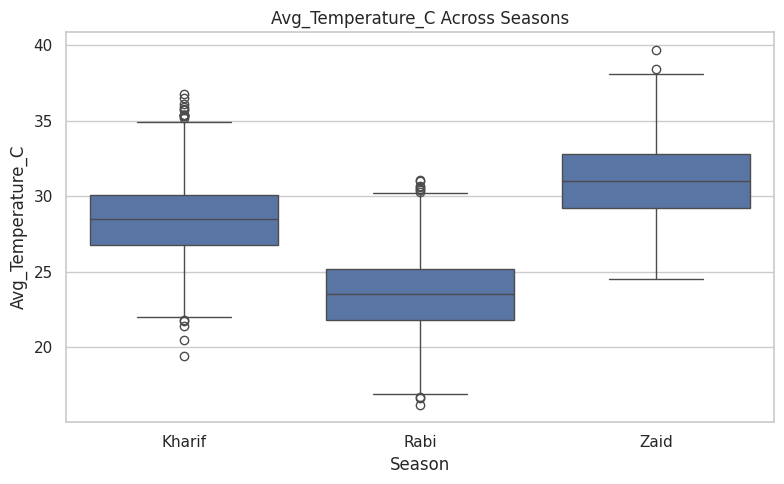

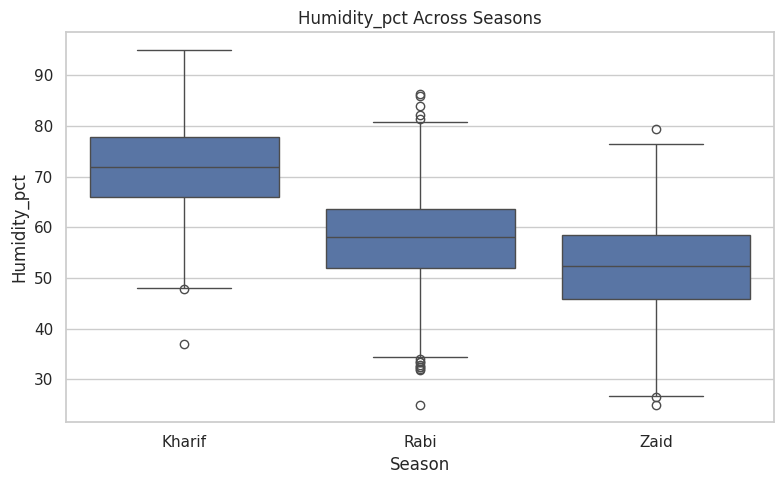

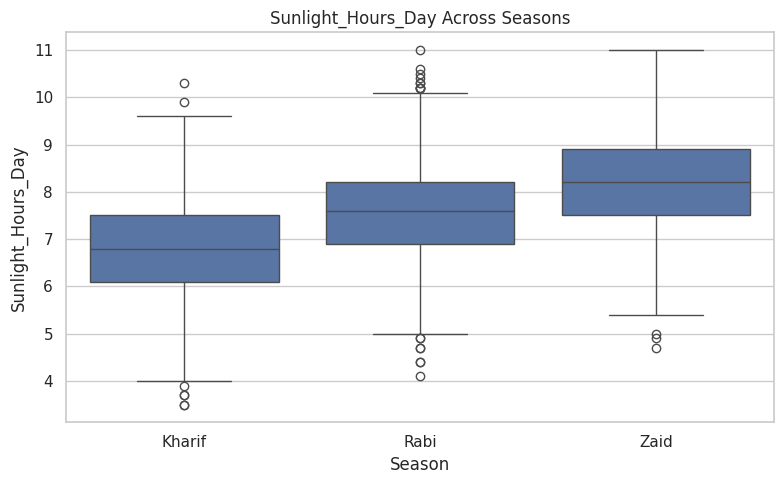

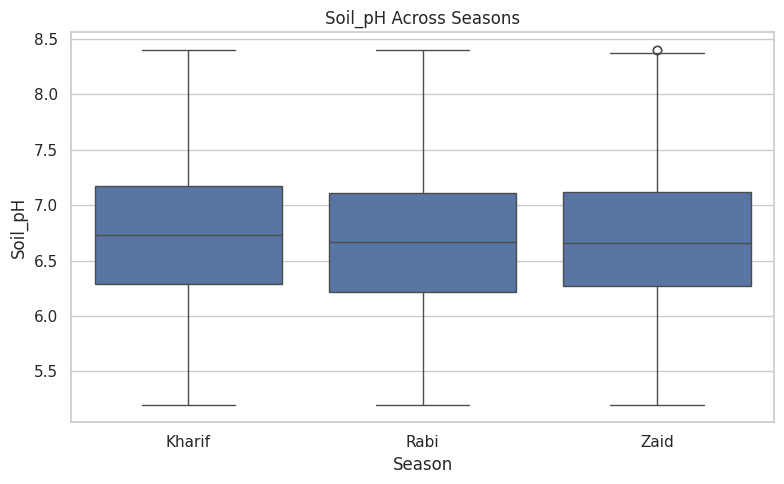

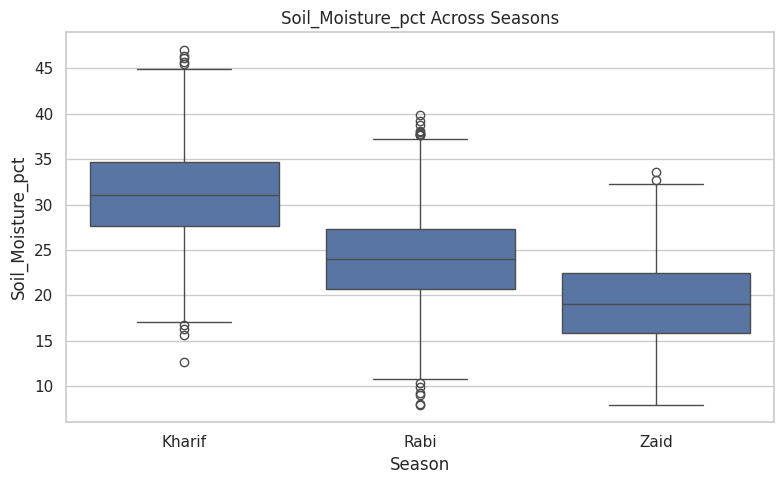

In [ ]:
for col in environmental_variables:
    plt.figure(figsize=(8,5))
    sns.boxplot(data=df, x="Season", y=col)
    plt.title(f"{col} Across Seasons")
    plt.xlabel("Season")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

## 15. Resource Usage Across Seasons

In [ ]:
resource_variables = [
    "Nitrogen_kg_ha", "Phosphorus_kg_ha", "Potassium_kg_ha",
    "Fertilizer_kg_ha", "Pesticide_Litre_ha", "Water_Used_m3"
]

resource_season = df.groupby("Season")[resource_variables].mean().round(2)
display(resource_season)

,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Fertilizer_kg_ha,Pesticide_Litre_ha,Water_Used_m3
Season,,,,,,
Kharif,120.02,58.10,105.30,187.08,5.08,"6,102.20"
Rabi,120.40,57.31,103.93,185.41,5.02,"5,846.99"
Zaid,120.53,58.13,105.42,184.64,5.17,"6,419.89"


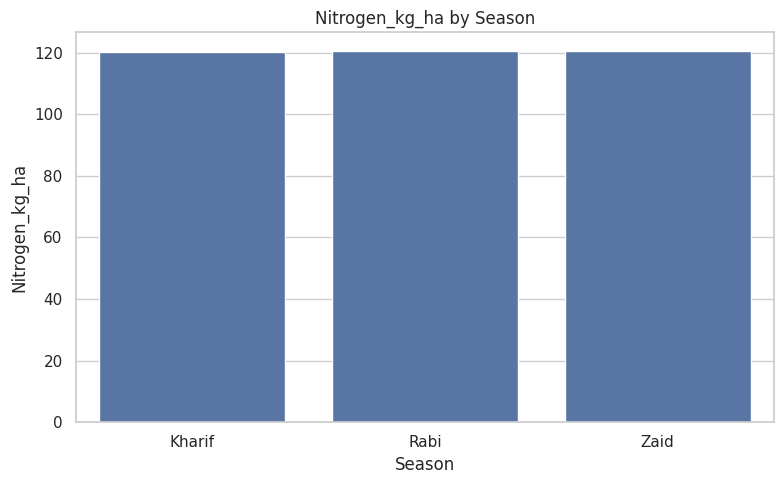

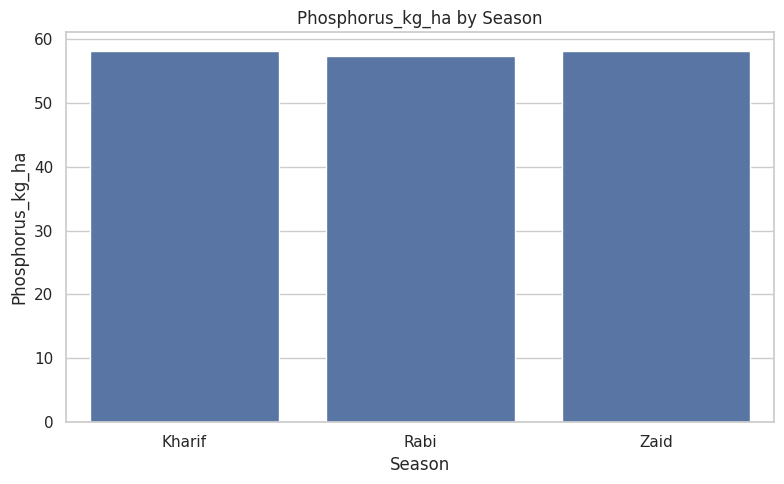

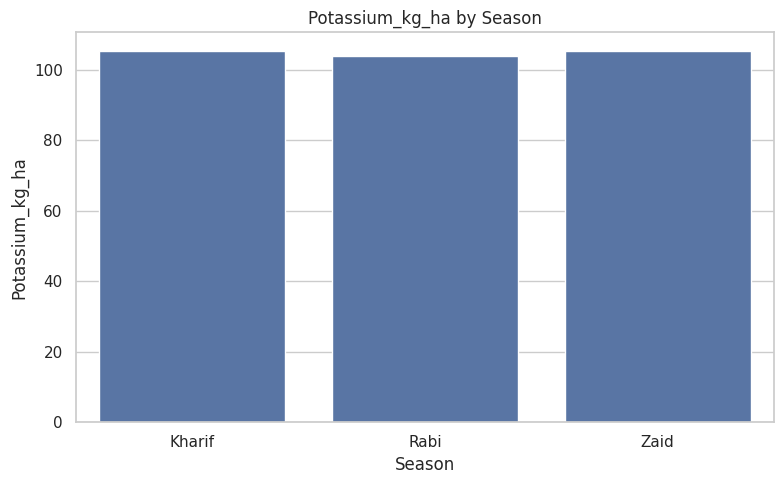

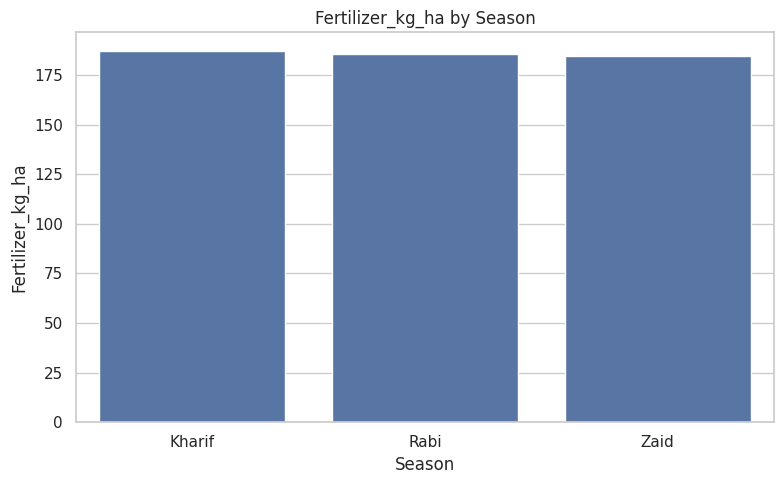

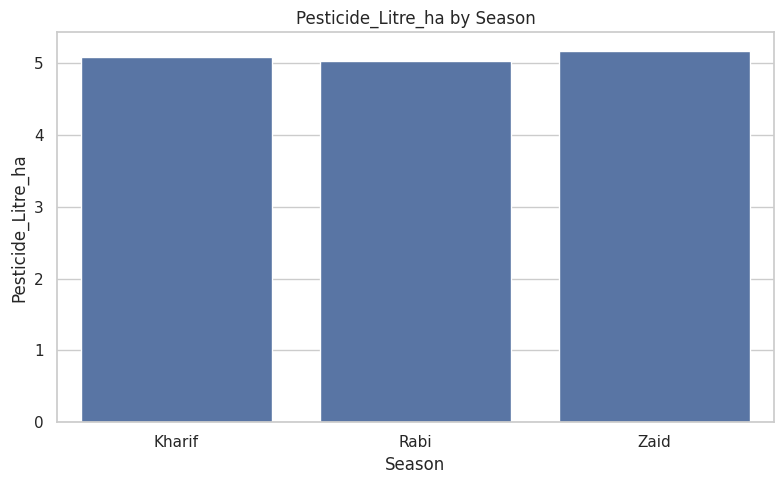

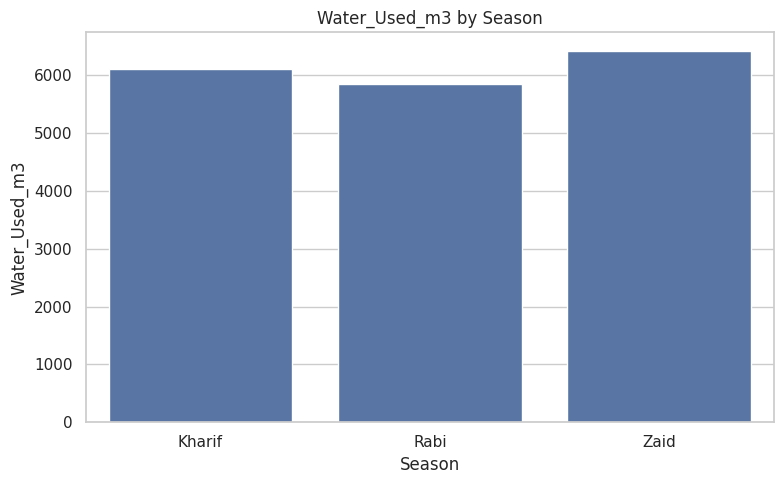

In [ ]:
for col in resource_variables:
    plt.figure(figsize=(8,5))
    sns.barplot(data=df, x="Season", y=col, estimator="mean", errorbar=None)
    plt.title(f"{col} by Season")
    plt.xlabel("Season")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

## 16. Irrigation Method Analysis

Irrigation_Method,Drip,Flood,Rainfed,Sprinkler
Season,,,,
Kharif,22.77,33.16,26.03,18.04
Rabi,22.74,32.33,26.92,18.01
Zaid,23.57,32.66,23.57,20.20


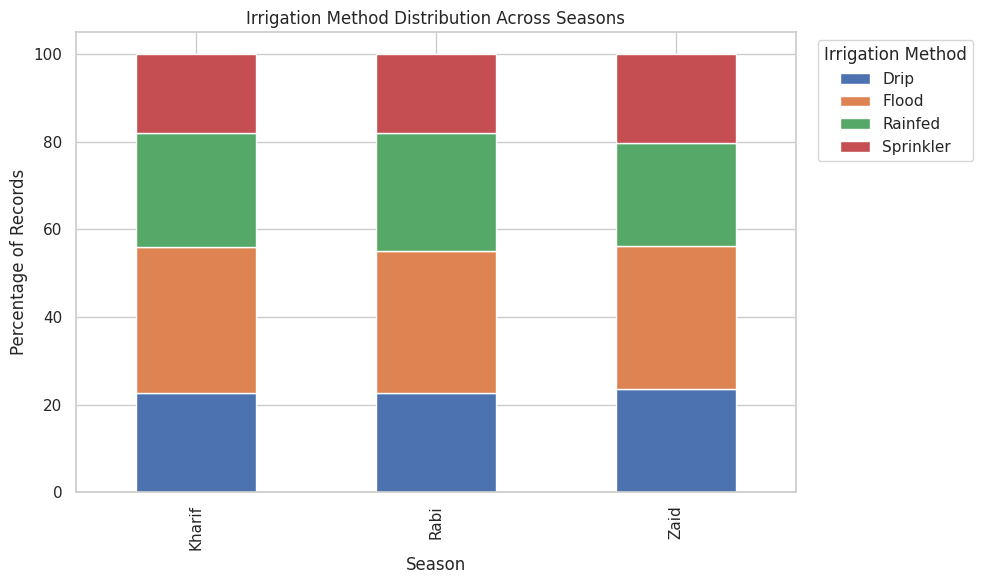

In [ ]:
irrigation_distribution = pd.crosstab(
    df["Season"], df["Irrigation_Method"], normalize="index"
).mul(100).round(2)

display(irrigation_distribution)

irrigation_distribution.plot(kind="bar", stacked=True, figsize=(10,6))
plt.title("Irrigation Method Distribution Across Seasons")
plt.xlabel("Season")
plt.ylabel("Percentage of Records")
plt.legend(title="Irrigation Method", bbox_to_anchor=(1.02,1), loc="upper left")
plt.tight_layout()
plt.show()

In [ ]:
irrigation_performance = df.groupby("Irrigation_Method").agg(
    Avg_Yield=("Yield_Tonnes_Ha","mean"),
    Avg_Production=("Production_Tonnes","mean"),
    Avg_Profit=("Profit_INR","mean"),
    Avg_Water_Used=("Water_Used_m3","mean"),
    Avg_Water_Efficiency=("Water_Efficiency_t_per_1000m3","mean")
).sort_values("Avg_Yield", ascending=False).round(2)

display(irrigation_performance)

,Avg_Yield,Avg_Production,Avg_Profit,Avg_Water_Used,Avg_Water_Efficiency
Irrigation_Method,,,,,
Drip,6.58,57.99,"219,626.00","5,918.75",6.27
Sprinkler,5.16,42.34,"91,121.08","6,208.26",4.67
Flood,4.86,38.73,"73,354.02","8,026.47",3.44
Rainfed,4.60,36.61,"79,050.37","3,549.55",7.56


## 17. Crop Performance

,Avg_Yield,Avg_Production,Avg_Revenue,Avg_Profit,Avg_Water_Efficiency,Avg_Disease_Risk
Crop,,,,,,
Sugarcane,46.64,392.41,"1,371,980.11","817,187.99",30.48,45.40
Chilli,1.54,12.38,"1,276,777.23","750,878.34",2.95,46.06
Cotton,1.23,9.40,"639,423.08","124,546.92",1.94,45.97
Groundnut,1.32,9.66,"542,935.50","44,858.12",3.15,46.29
Pulses,0.92,7.40,"528,465.87","-4,238.05",2.90,46.57
Maize,2.71,21.78,"457,067.99","-83,978.33",5.60,45.54
Rice,2.43,19.29,"423,615.26","-102,213.50",1.95,46.50
Wheat,2.11,16.85,"400,104.89","-123,398.34",4.63,47.85


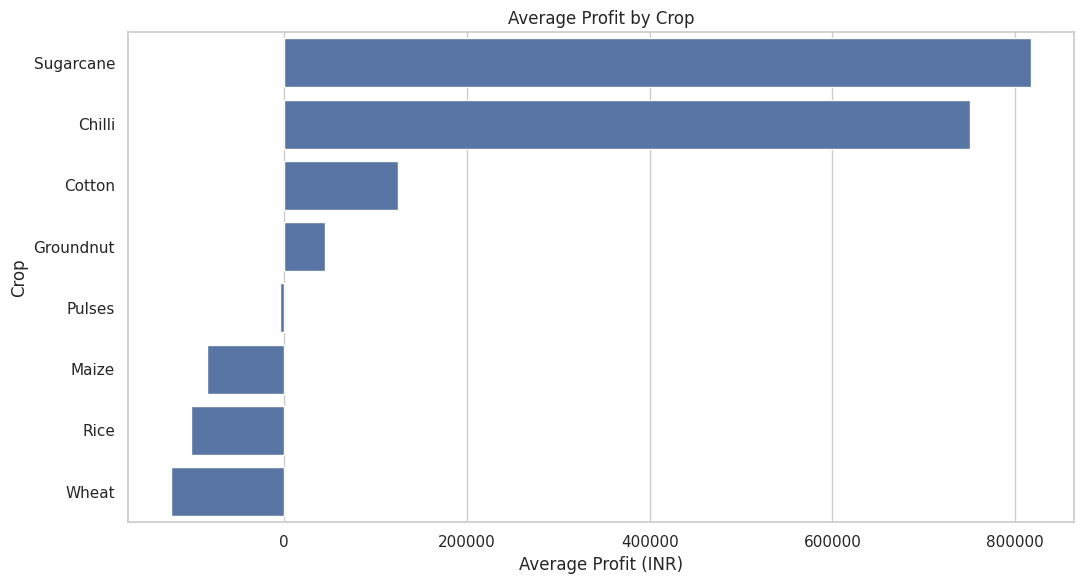

In [ ]:
crop_performance = df.groupby("Crop").agg(
    Avg_Yield=("Yield_Tonnes_Ha","mean"),
    Avg_Production=("Production_Tonnes","mean"),
    Avg_Revenue=("Revenue_INR","mean"),
    Avg_Profit=("Profit_INR","mean"),
    Avg_Water_Efficiency=("Water_Efficiency_t_per_1000m3","mean"),
    Avg_Disease_Risk=("Disease_Pest_Risk_pct","mean")
).sort_values("Avg_Profit", ascending=False).round(2)

display(crop_performance)

plt.figure(figsize=(11,6))
sns.barplot(data=crop_performance.reset_index(), y="Crop", x="Avg_Profit")
plt.title("Average Profit by Crop")
plt.xlabel("Average Profit (INR)")
plt.ylabel("Crop")
plt.tight_layout()
plt.show()

## 18. Crop × Season Analysis

This checks whether seasonal effects are consistent across crops.

Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,1.73,1.47,1.20
Cotton,1.37,1.20,0.96
Groundnut,1.48,1.23,1.04
Maize,2.97,2.60,2.29
Pulses,1.04,0.88,0.67
Rice,2.70,2.32,1.90
Sugarcane,53.46,43.29,38.42
Wheat,2.25,2.06,1.75


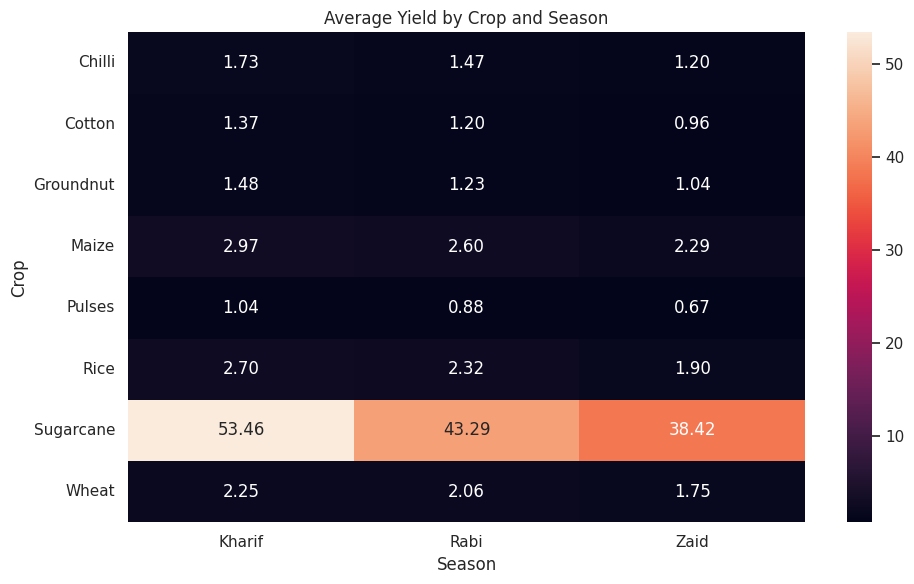

In [ ]:
crop_season_yield = pd.pivot_table(
    df, values="Yield_Tonnes_Ha", index="Crop", columns="Season", aggfunc="mean"
)

display(crop_season_yield.round(2))

plt.figure(figsize=(10,6))
sns.heatmap(crop_season_yield, annot=True, fmt=".2f")
plt.title("Average Yield by Crop and Season")
plt.xlabel("Season")
plt.ylabel("Crop")
plt.tight_layout()
plt.show()

In [ ]:
crop_season_profit = pd.pivot_table(
    df, values="Profit_INR", index="Crop", columns="Season", aggfunc="mean"
)
display(crop_season_profit.round(2))

Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,"954,380.42","638,572.50","448,659.09"
Cotton,"216,999.55","107,343.59","-53,925.34"
Groundnut,"108,265.44","10,416.54","-68,872.50"
Maize,"-39,332.67","-89,133.40","-194,049.17"
Pulses,"43,338.90","-14,309.14","-139,227.81"
Rice,"-64,903.40","-98,427.87","-227,239.34"
Sugarcane,"1,000,790.81","731,612.86","583,635.80"
Wheat,"-105,871.87","-119,954.57","-193,208.95"


In [ ]:
df.columns.tolist()

['Farm_ID',
 'State',
 'District',
 'Crop',
 'Season',
 'Farm_Area_Hectares',
 'Rainfall_mm',
 'Avg_Temperature_C',
 'Humidity_pct',
 'Sunlight_Hours_Day',
 'Soil_pH',
 'Soil_Moisture_pct',
 'Nitrogen_kg_ha',
 'Phosphorus_kg_ha',
 'Potassium_kg_ha',
 'Irrigation_Method',
 'Fertilizer_kg_ha',
 'Pesticide_Litre_ha',
 'Seed_Quality_Score',
 'Yield_Tonnes_Ha',
 'Production_Tonnes',
 'Market_Price_INR_Tonne',
 'Total_Cost_INR',
 'Revenue_INR',
 'Profit_INR',
 'Water_Used_m3',
 'Water_Efficiency_t_per_1000m3',
 'Disease_Pest_Risk_pct',
 'Profit_Margin_pct',
 'Cost_per_Hectare',
 'Revenue_per_Hectare',
 'Profit_per_Hectare',
 'Production_per_Hectare']

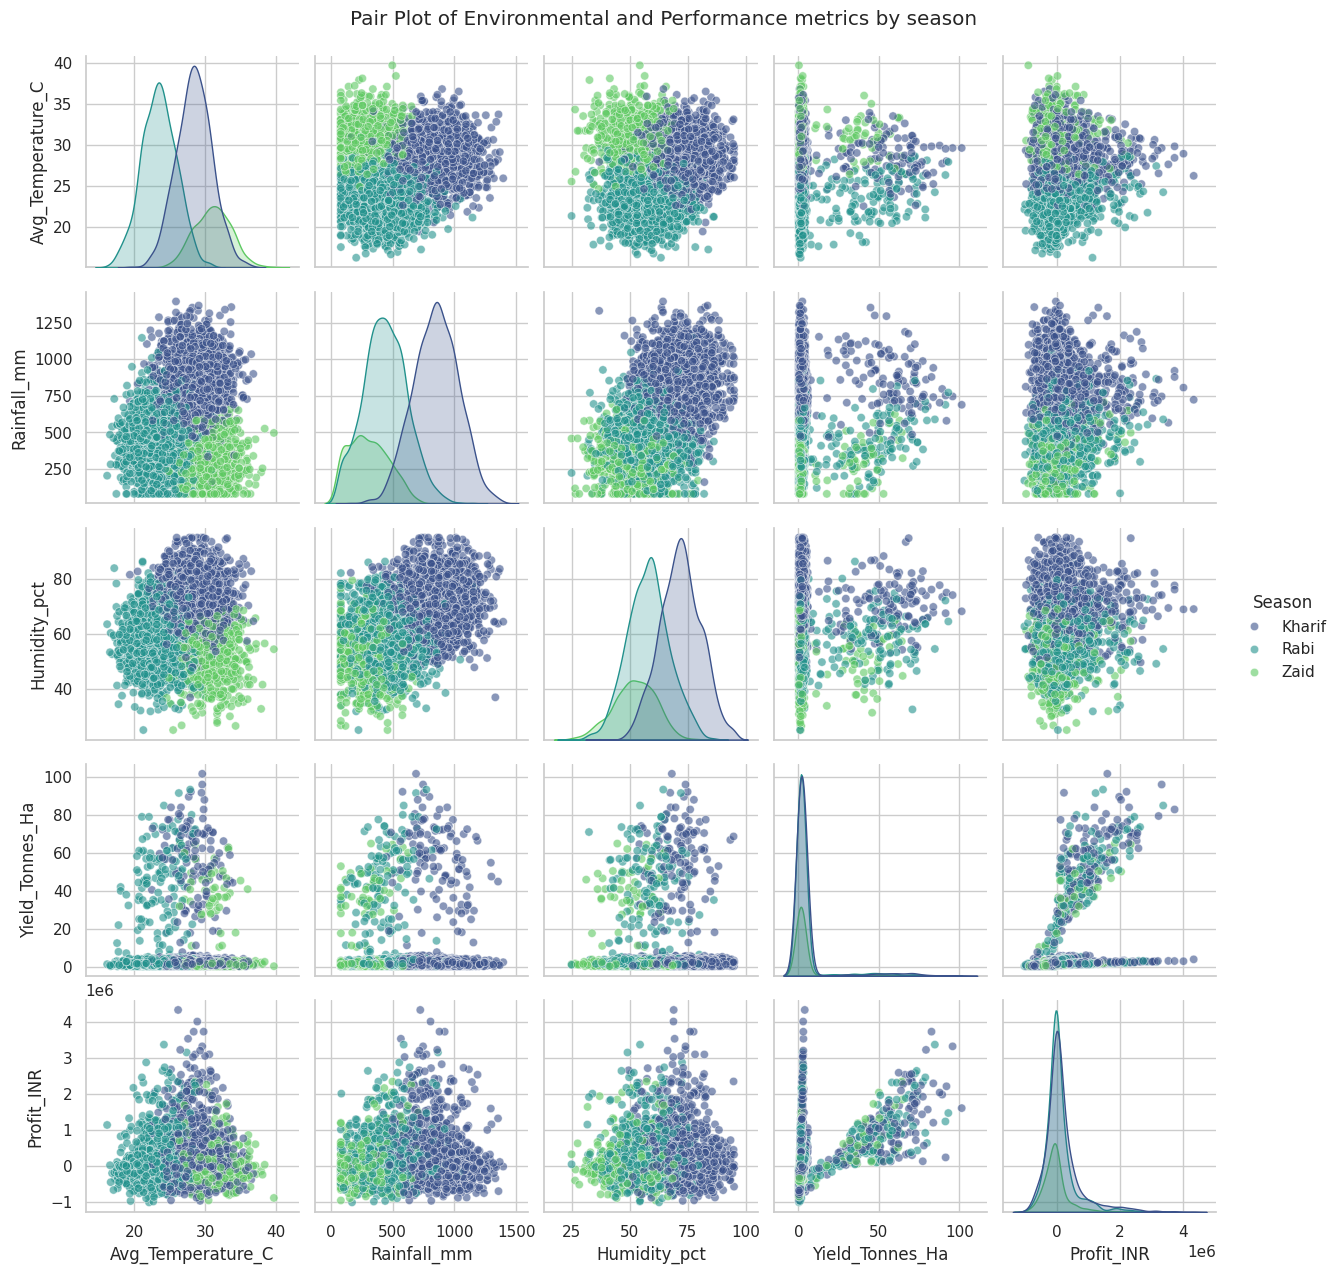

In [ ]:
selected_columns= ['Avg_Temperature_C','Rainfall_mm','Humidity_pct', 'Yield_Tonnes_Ha','Profit_INR','Season']
sns.pairplot(df[selected_columns], hue='Season',palette='viridis',plot_kws={'alpha':0.6})
plt.suptitle('Pair Plot of Environmental and Performance metrics by season',y=1.02)
plt.show()

## 19. Regional Analysis

,Avg_Yield,Avg_Production,Avg_Revenue,Avg_Profit,Avg_Water_Efficiency,Avg_Disease_Risk
State,,,,,,
Punjab,6.12,52.23,"686,225.70","136,025.64",5.62,46.00
Maharashtra,5.02,43.98,"650,032.67","135,428.86",5.28,46.44
Karnataka,5.69,47.73,"653,426.18","119,422.34",5.56,46.06
Tamil Nadu,4.88,40.84,"629,093.42","117,744.75",5.31,46.28
Gujarat,5.66,48.33,"654,692.86","117,568.24",5.58,45.95
Telangana,5.04,39.25,"628,784.53","108,829.62",5.46,46.36
Madhya Pradesh,4.99,37.56,"597,558.36","86,840.76",5.27,47.08
Andhra Pradesh,4.63,36.91,"606,663.66","73,453.53",5.03,46.72


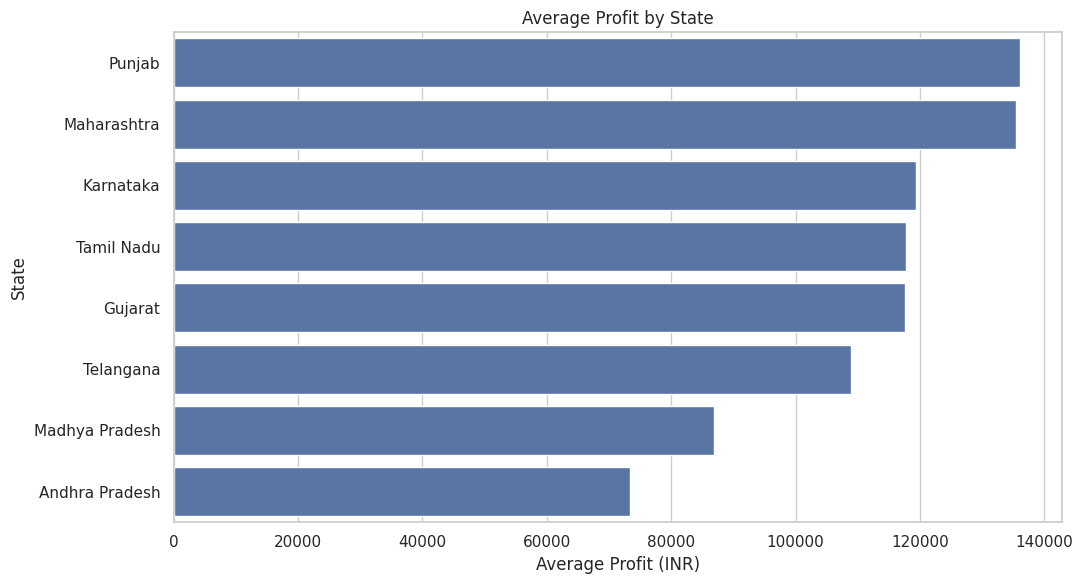

In [ ]:
state_performance = df.groupby("State").agg(
    Avg_Yield=("Yield_Tonnes_Ha","mean"),
    Avg_Production=("Production_Tonnes","mean"),
    Avg_Revenue=("Revenue_INR","mean"),
    Avg_Profit=("Profit_INR","mean"),
    Avg_Water_Efficiency=("Water_Efficiency_t_per_1000m3","mean"),
    Avg_Disease_Risk=("Disease_Pest_Risk_pct","mean")
).sort_values("Avg_Profit", ascending=False).round(2)

display(state_performance)

plt.figure(figsize=(11,6))
sns.barplot(data=state_performance.reset_index(), y="State", x="Avg_Profit")
plt.title("Average Profit by State")
plt.xlabel("Average Profit (INR)")
plt.ylabel("State")
plt.tight_layout()
plt.show()

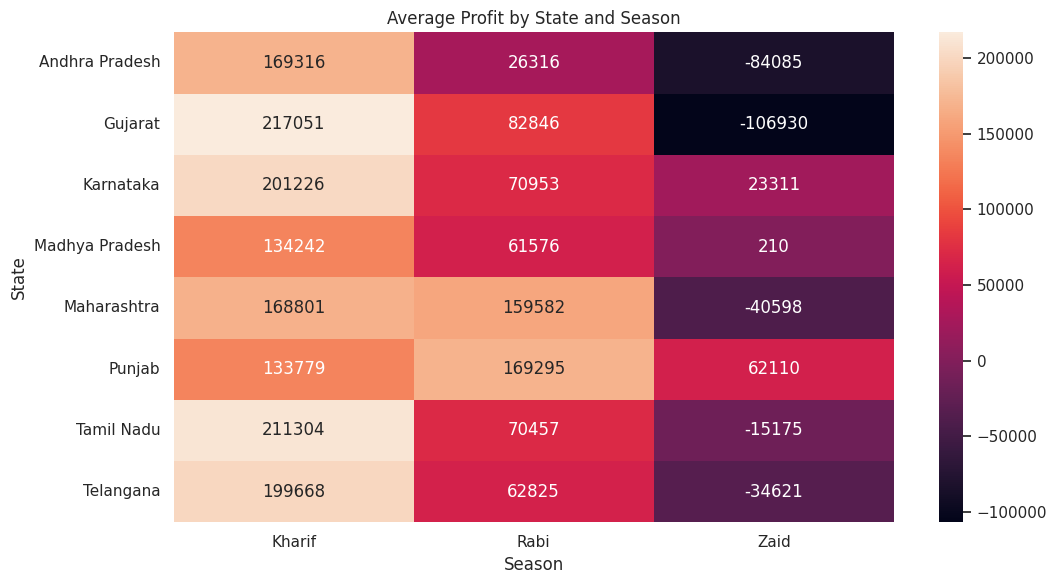

In [ ]:
state_season_profit = pd.pivot_table(
    df, values="Profit_INR", index="State", columns="Season", aggfunc="mean"
)

plt.figure(figsize=(11,6))
sns.heatmap(state_season_profit, annot=True, fmt=".0f")
plt.title("Average Profit by State and Season")
plt.xlabel("Season")
plt.ylabel("State")
plt.tight_layout()
plt.show()

## 20. Water Efficiency Analysis

,Average Water Efficiency
Season,
Kharif,5.89
Rabi,5.19
Zaid,4.41


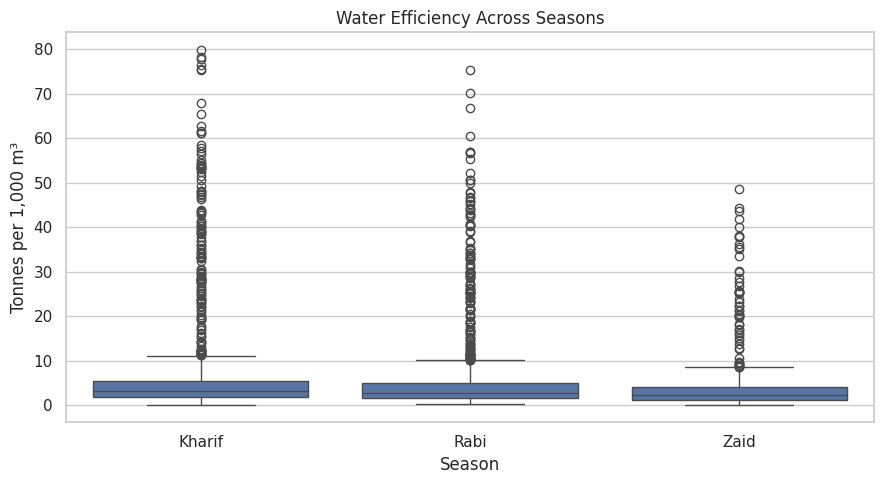

,Average Water Efficiency
Irrigation_Method,
Rainfed,7.56
Drip,6.27
Sprinkler,4.67
Flood,3.44


In [ ]:
water_by_season = df.groupby("Season")["Water_Efficiency_t_per_1000m3"].mean().sort_values(ascending=False)
display(water_by_season.round(2).to_frame("Average Water Efficiency"))

plt.figure(figsize=(9,5))
sns.boxplot(data=df, x="Season", y="Water_Efficiency_t_per_1000m3")
plt.title("Water Efficiency Across Seasons")
plt.xlabel("Season")
plt.ylabel("Tonnes per 1,000 m³")
plt.tight_layout()
plt.show()

water_by_irrigation = df.groupby("Irrigation_Method")["Water_Efficiency_t_per_1000m3"].mean().sort_values(ascending=False)
display(water_by_irrigation.round(2).to_frame("Average Water Efficiency"))

## 21. Disease and Pest Risk

,mean,median,max
Season,,,
Kharif,54.47,54.50,88.90
Rabi,40.48,40.60,71.20
Zaid,38.22,37.90,71.60


,Average Disease/Pest Risk %
Crop,
Wheat,47.85
Pulses,46.57
Rice,46.50
Groundnut,46.29
Chilli,46.06
Cotton,45.97
Maize,45.54
Sugarcane,45.40


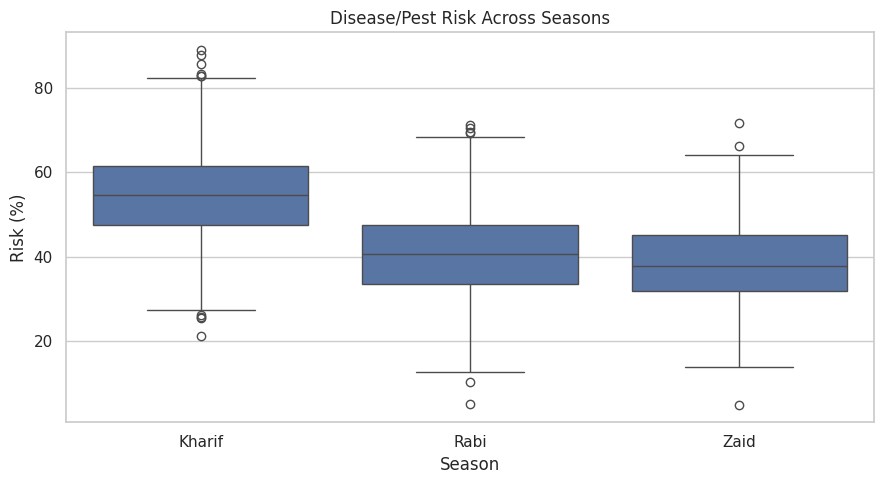

In [ ]:
disease_season = df.groupby("Season")["Disease_Pest_Risk_pct"].agg(["mean","median","max"]).round(2)
display(disease_season)

disease_crop = df.groupby("Crop")["Disease_Pest_Risk_pct"].mean().sort_values(ascending=False)
display(disease_crop.round(2).to_frame("Average Disease/Pest Risk %"))

plt.figure(figsize=(9,5))
sns.boxplot(data=df, x="Season", y="Disease_Pest_Risk_pct")
plt.title("Disease/Pest Risk Across Seasons")
plt.xlabel("Season")
plt.ylabel("Risk (%)")
plt.tight_layout()
plt.show()

## 22. Seed Quality and Yield

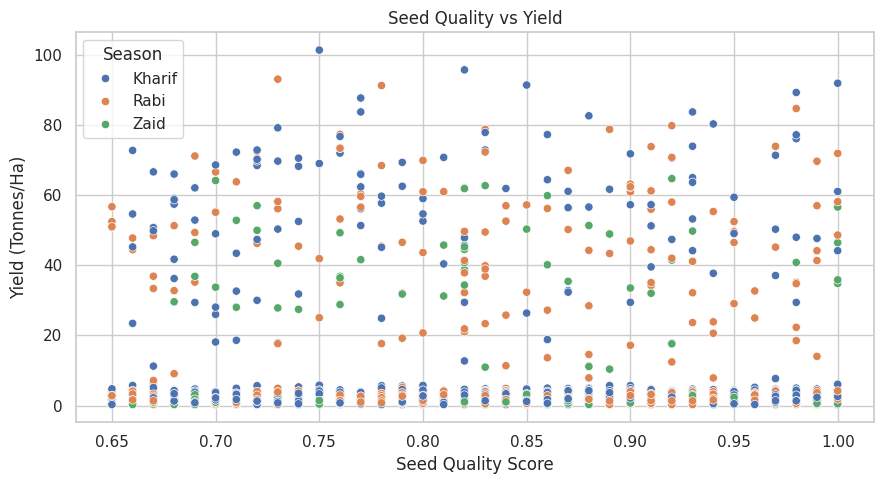

In [ ]:
plt.figure(figsize=(9,5))
sns.scatterplot(data=df, x="Seed_Quality_Score", y="Yield_Tonnes_Ha", hue="Season")
plt.title("Seed Quality vs Yield")
plt.xlabel("Seed Quality Score")
plt.ylabel("Yield (Tonnes/Ha)")
plt.tight_layout()
plt.show()

##EDA
MORE VISUALS

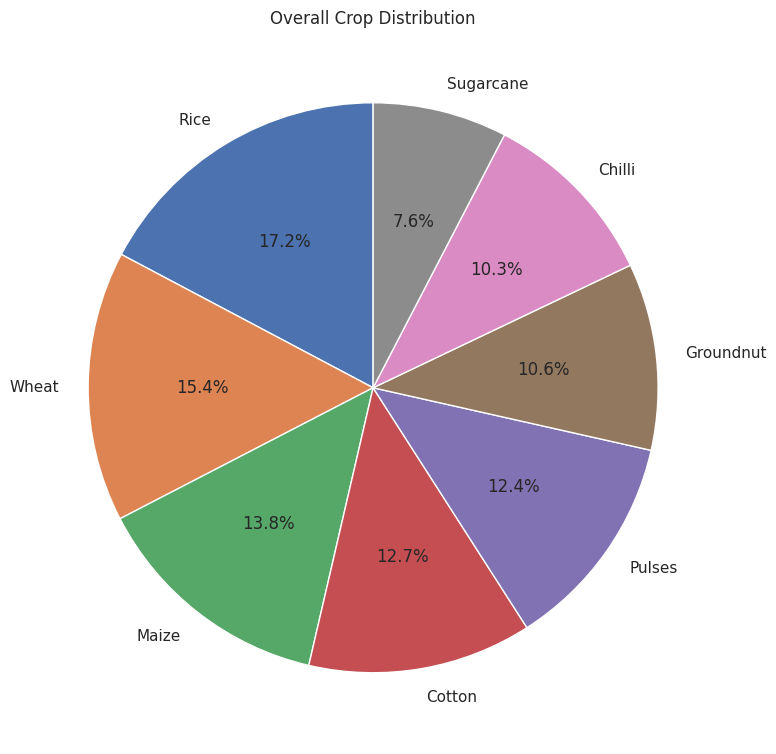

In [ ]:
# Crop Distribution

crop_counts = df["Crop"].value_counts()

plt.figure(figsize=(8, 8))

plt.pie(
    crop_counts.values,
    labels=crop_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Overall Crop Distribution")
plt.tight_layout()
plt.show()

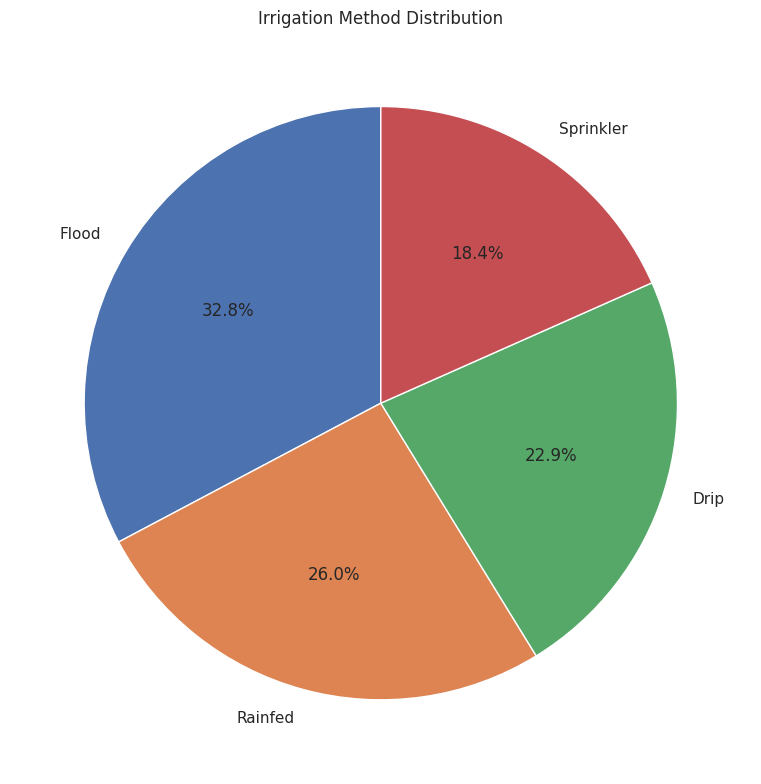

In [ ]:
# Irrigation Method Distribution

irrigation_counts = df["Irrigation_Method"].value_counts()

plt.figure(figsize=(8, 8))

plt.pie(
    irrigation_counts.values,
    labels=irrigation_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Irrigation Method Distribution")
plt.tight_layout()
plt.show()

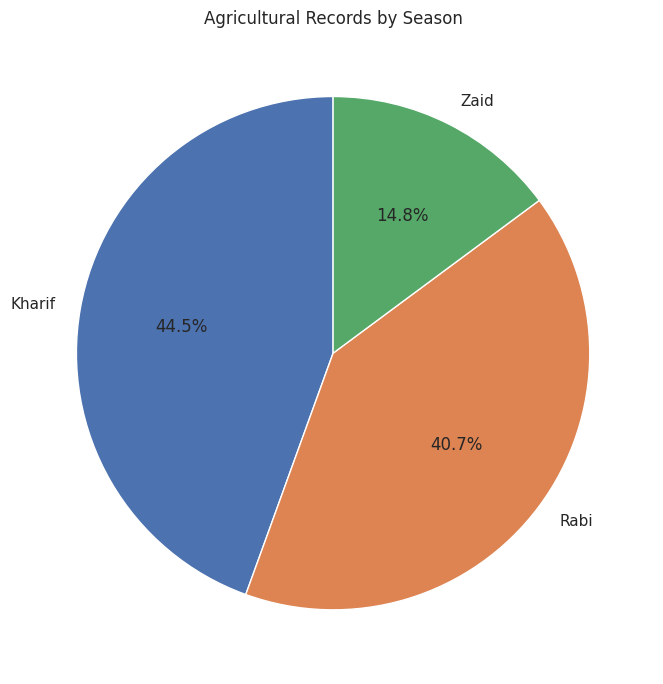

In [ ]:
# Seasonal Distribution

season_counts = df["Season"].value_counts()

plt.figure(figsize=(7, 7))

plt.pie(
    season_counts.values,
    labels=season_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Agricultural Records by Season")
plt.tight_layout()
plt.show()

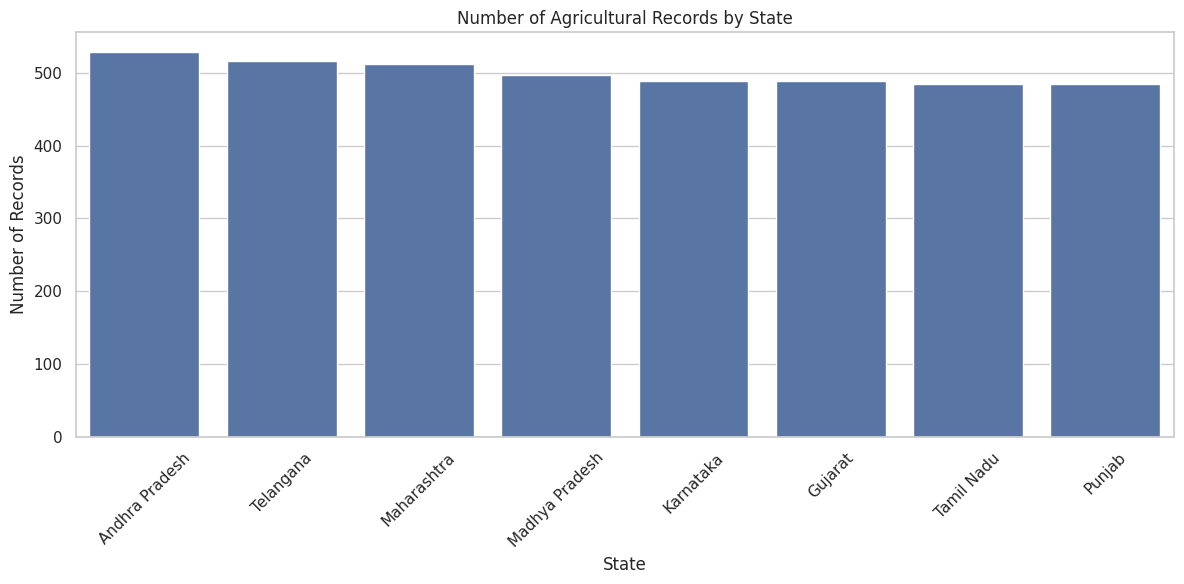

In [ ]:
plt.figure(figsize=(12, 6))

state_counts = df["State"].value_counts()

sns.barplot(
    x=state_counts.index,
    y=state_counts.values
)

plt.title("Number of Agricultural Records by State")
plt.xlabel("State")
plt.ylabel("Number of Records")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

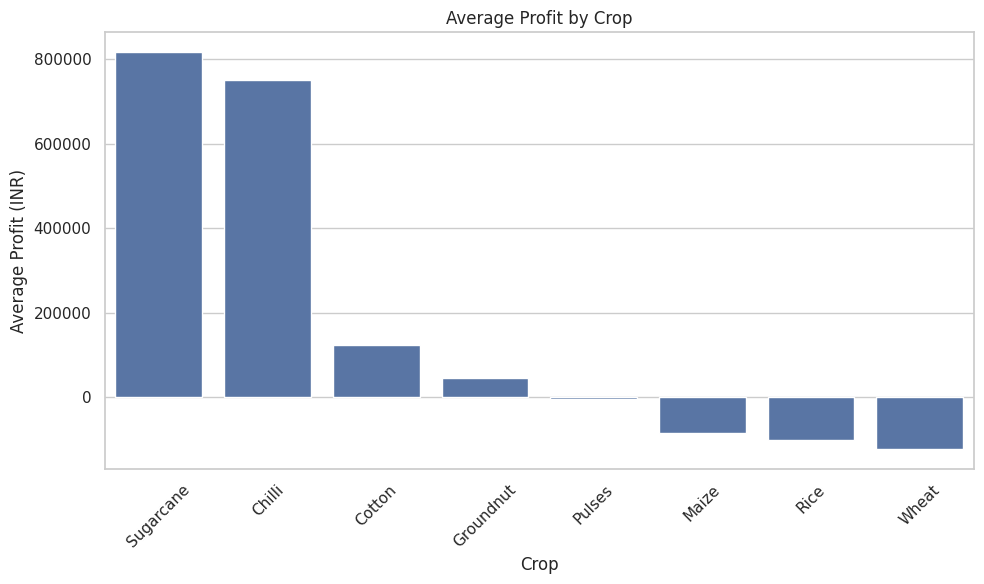

In [ ]:
crop_profit = (
    df.groupby("Crop")["Profit_INR"]
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=crop_profit.index,
    y=crop_profit.values
)

plt.title("Average Profit by Crop")
plt.xlabel("Crop")
plt.ylabel("Average Profit (INR)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

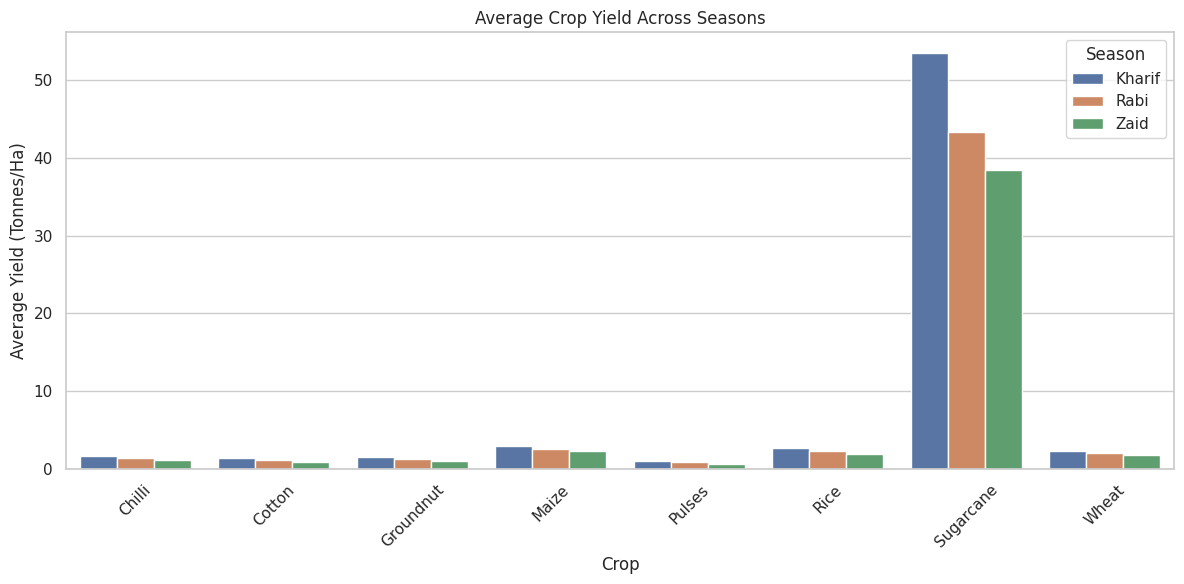

In [ ]:
crop_season_yield = (
    df.groupby(["Crop", "Season"])["Yield_Tonnes_Ha"]
      .mean()
      .reset_index()
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=crop_season_yield,
    x="Crop",
    y="Yield_Tonnes_Ha",
    hue="Season"
)

plt.title("Average Crop Yield Across Seasons")
plt.xlabel("Crop")
plt.ylabel("Average Yield (Tonnes/Ha)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

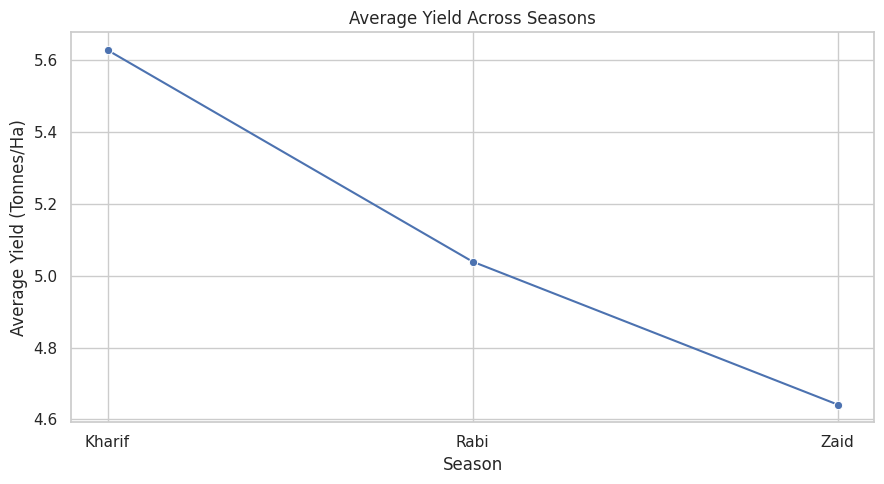

In [ ]:
season_yield = (
    df.groupby("Season")["Yield_Tonnes_Ha"]
      .mean()
      .reset_index()
)

plt.figure(figsize=(9, 5))

sns.lineplot(
    data=season_yield,
    x="Season",
    y="Yield_Tonnes_Ha",
    marker="o"
)

plt.title("Average Yield Across Seasons")
plt.xlabel("Season")
plt.ylabel("Average Yield (Tonnes/Ha)")

plt.tight_layout()
plt.show()

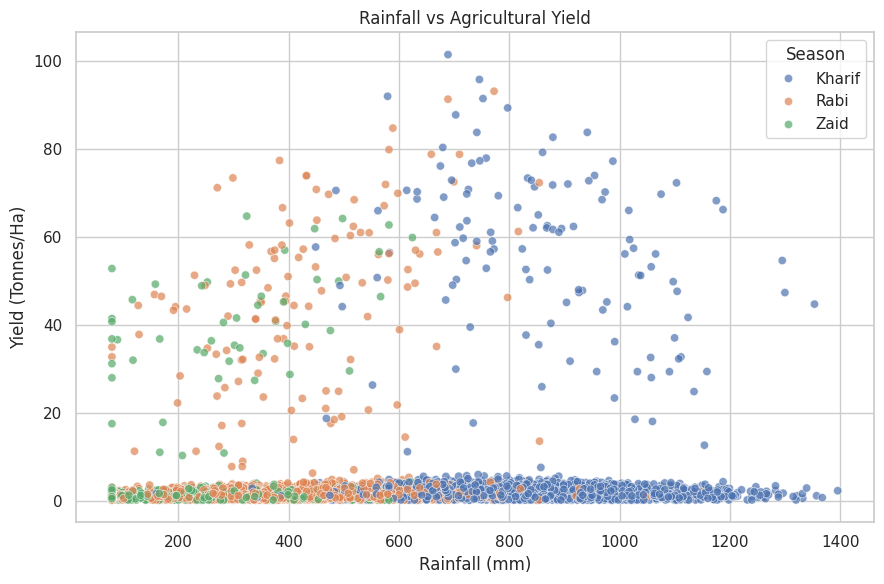

In [ ]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="Rainfall_mm",
    y="Yield_Tonnes_Ha",
    hue="Season",
    alpha=0.7
)

plt.title("Rainfall vs Agricultural Yield")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Yield (Tonnes/Ha)")

plt.tight_layout()
plt.show()

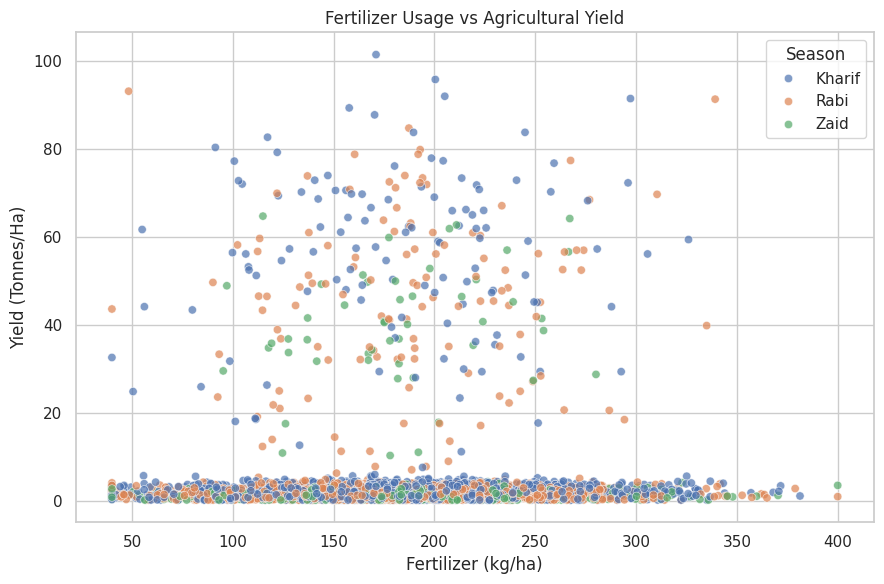

In [ ]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="Fertilizer_kg_ha",
    y="Yield_Tonnes_Ha",
    hue="Season",
    alpha=0.7
)

plt.title("Fertilizer Usage vs Agricultural Yield")
plt.xlabel("Fertilizer (kg/ha)")
plt.ylabel("Yield (Tonnes/Ha)")

plt.tight_layout()
plt.show()

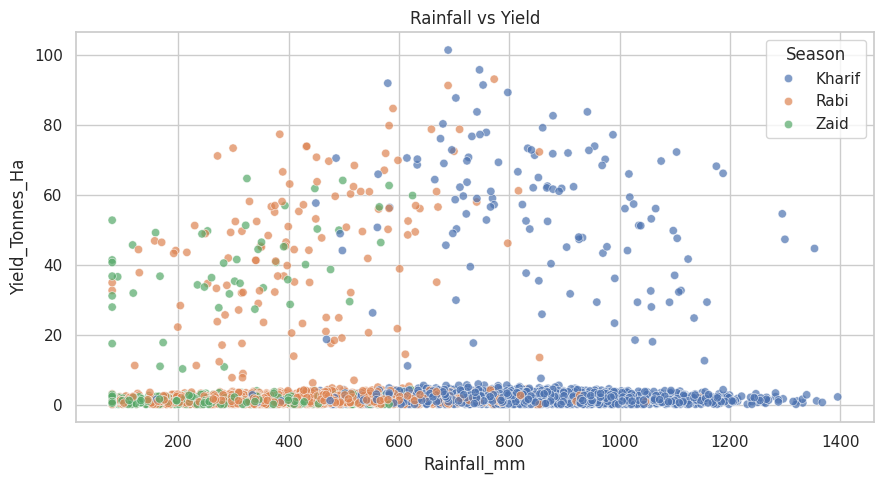

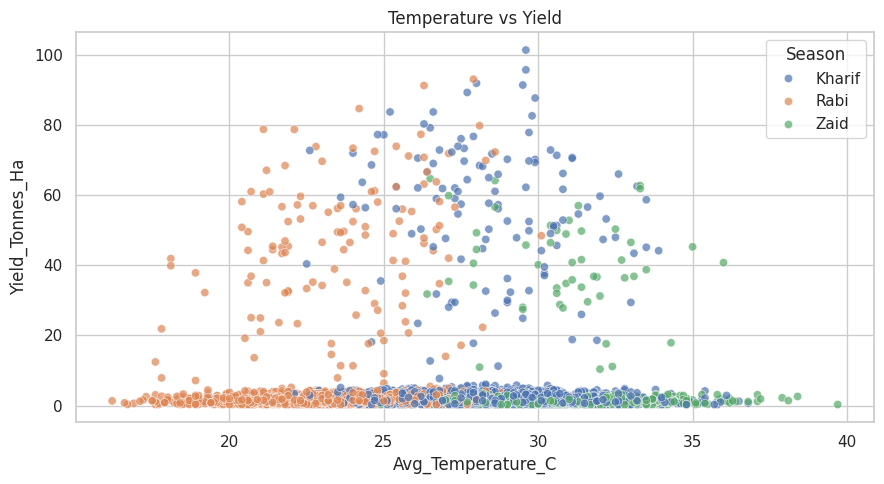

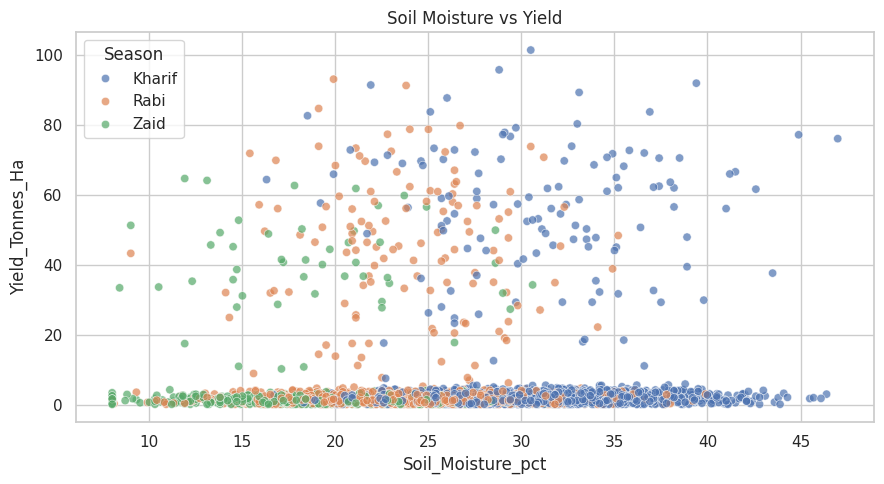

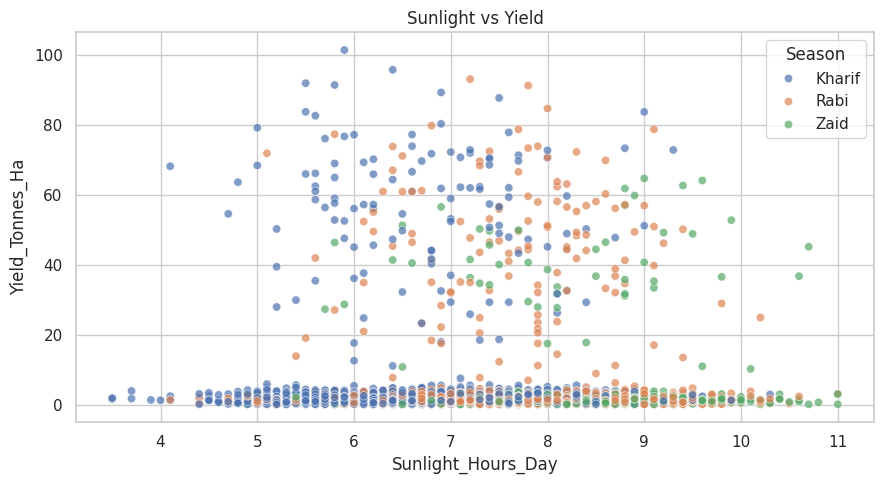

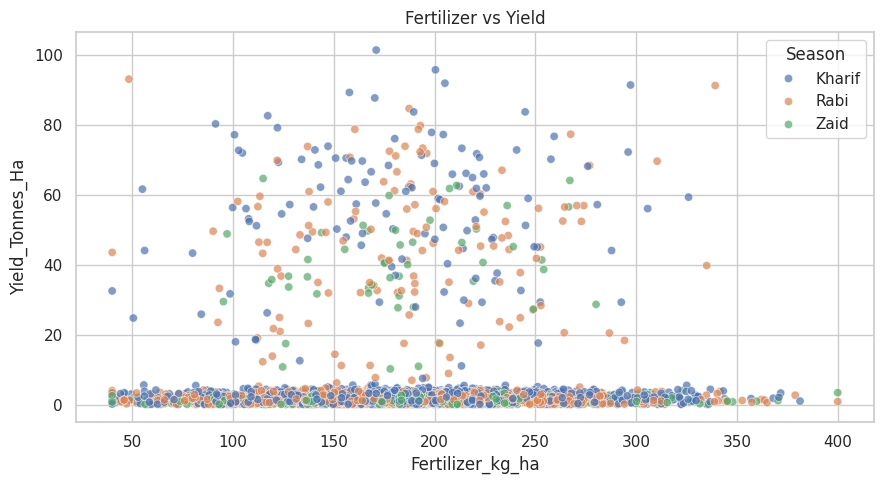

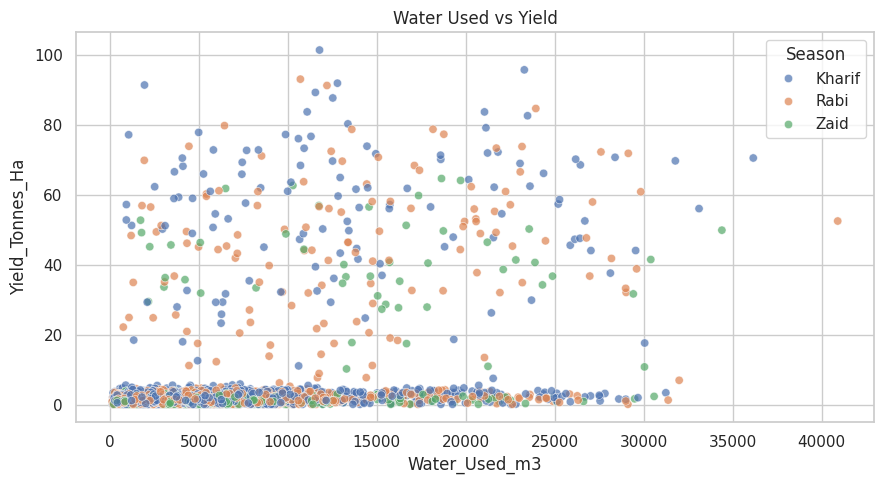

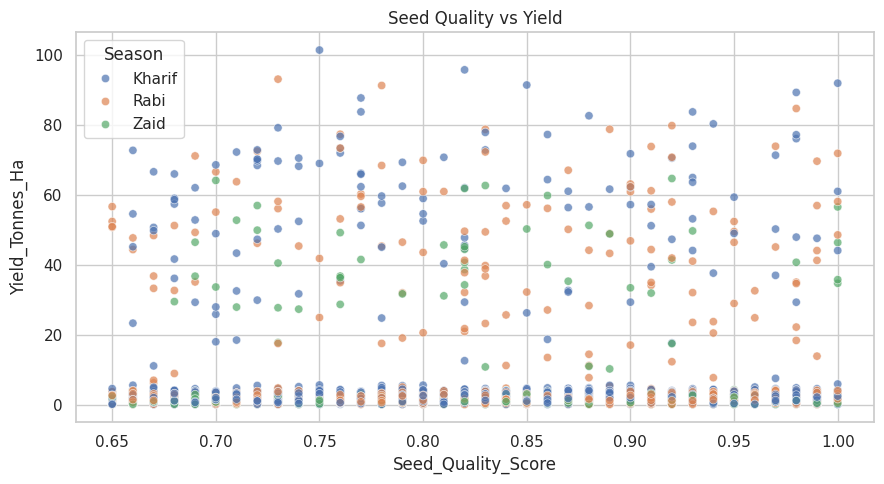

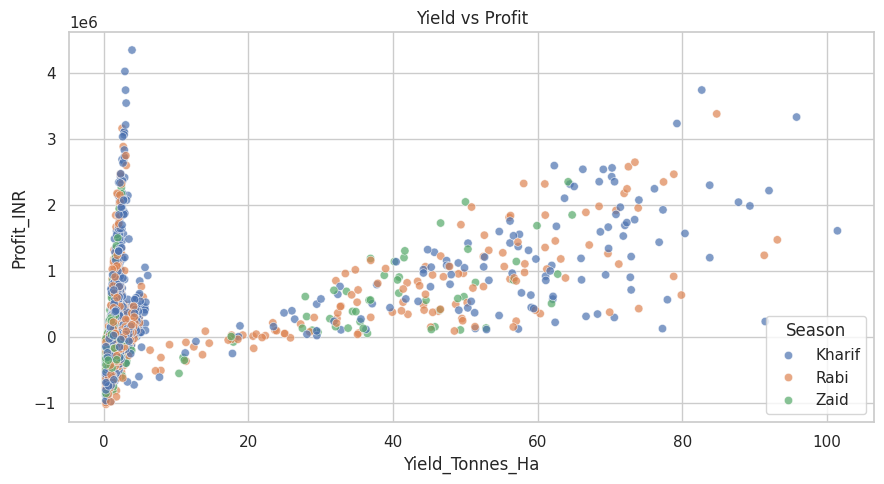

In [ ]:
relationship_pairs = [
    ("Rainfall_mm", "Yield_Tonnes_Ha", "Rainfall vs Yield"),
    ("Avg_Temperature_C", "Yield_Tonnes_Ha", "Temperature vs Yield"),
    ("Soil_Moisture_pct", "Yield_Tonnes_Ha", "Soil Moisture vs Yield"),
    ("Sunlight_Hours_Day", "Yield_Tonnes_Ha", "Sunlight vs Yield"),
    ("Fertilizer_kg_ha", "Yield_Tonnes_Ha", "Fertilizer vs Yield"),
    ("Water_Used_m3", "Yield_Tonnes_Ha", "Water Used vs Yield"),
    ("Seed_Quality_Score", "Yield_Tonnes_Ha", "Seed Quality vs Yield"),
    ("Yield_Tonnes_Ha", "Profit_INR", "Yield vs Profit")
]

for x_col, y_col, title in relationship_pairs:

    plt.figure(figsize=(9, 5))

    sns.scatterplot(
        data=df,
        x=x_col,
        y=y_col,
        hue="Season",
        alpha=0.7
    )

    plt.title(title)
    plt.xlabel(x_col)
    plt.ylabel(y_col)

    plt.tight_layout()
    plt.show()

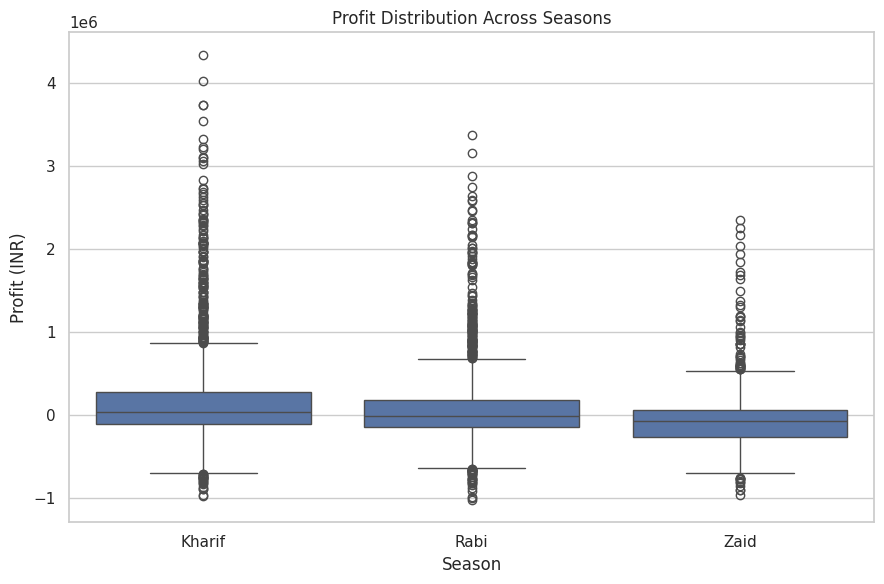

In [ ]:
plt.figure(figsize=(9, 6))

sns.boxplot(
    data=df,
    x="Season",
    y="Profit_INR"
)

plt.title("Profit Distribution Across Seasons")
plt.xlabel("Season")
plt.ylabel("Profit (INR)")

plt.tight_layout()
plt.show()

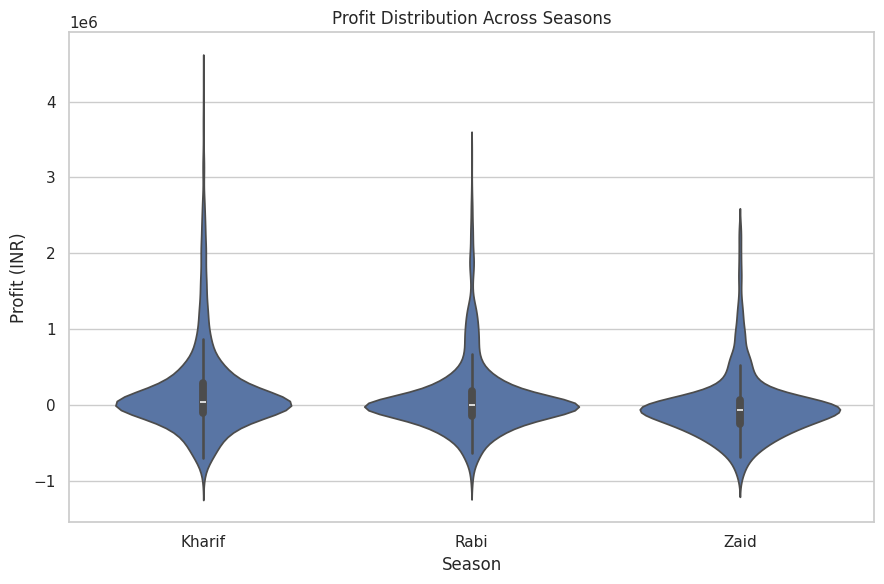

In [ ]:
plt.figure(figsize=(9, 6))

sns.violinplot(
    data=df,
    x="Season",
    y="Profit_INR"
)

plt.title("Profit Distribution Across Seasons")
plt.xlabel("Season")
plt.ylabel("Profit (INR)")

plt.tight_layout()
plt.show()

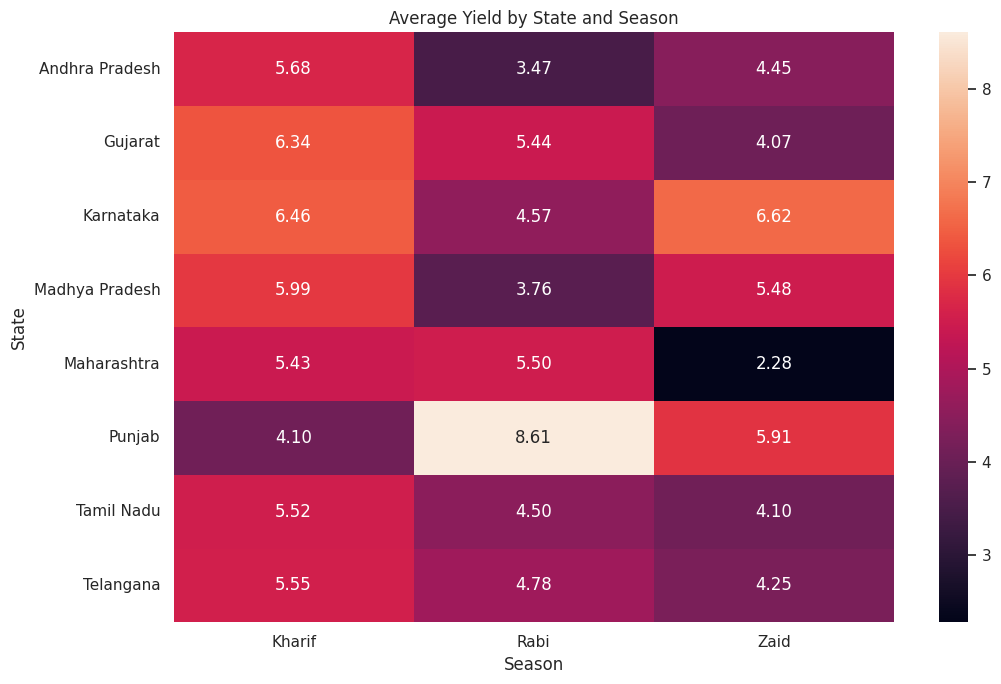

In [ ]:
state_season = pd.pivot_table(
    df,
    values="Yield_Tonnes_Ha",
    index="State",
    columns="Season",
    aggfunc="mean"
)

plt.figure(figsize=(11, 7))

sns.heatmap(
    state_season,
    annot=True,
    fmt=".2f"
)

plt.title("Average Yield by State and Season")
plt.xlabel("Season")
plt.ylabel("State")

plt.tight_layout()
plt.show()

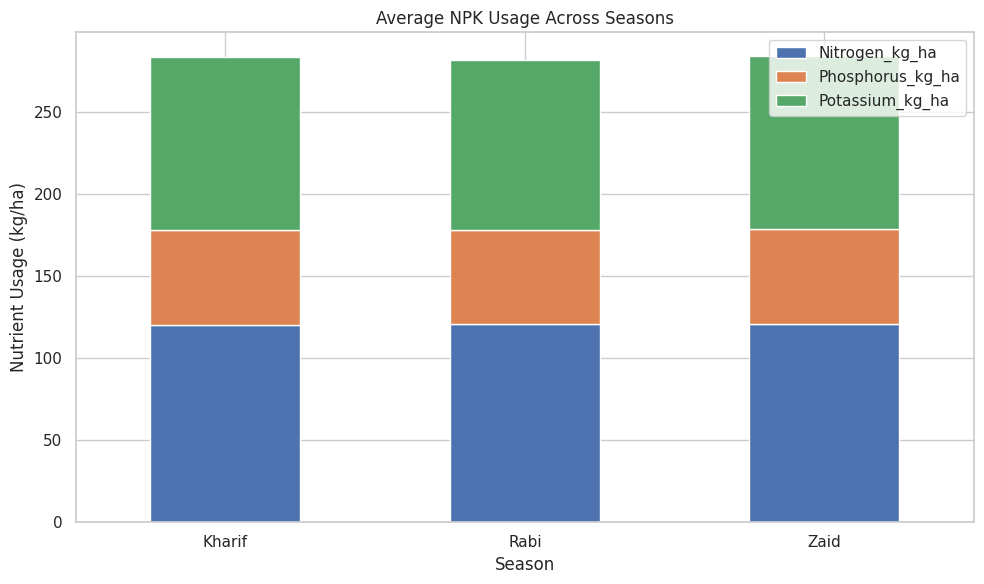

In [ ]:
npk_season = (
    df.groupby("Season")[
        ["Nitrogen_kg_ha", "Phosphorus_kg_ha", "Potassium_kg_ha"]
    ]
    .mean()
)

npk_season.plot(
    kind="bar",
    figsize=(10, 6),
    stacked=True
)

plt.title("Average NPK Usage Across Seasons")
plt.xlabel("Season")
plt.ylabel("Nutrient Usage (kg/ha)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

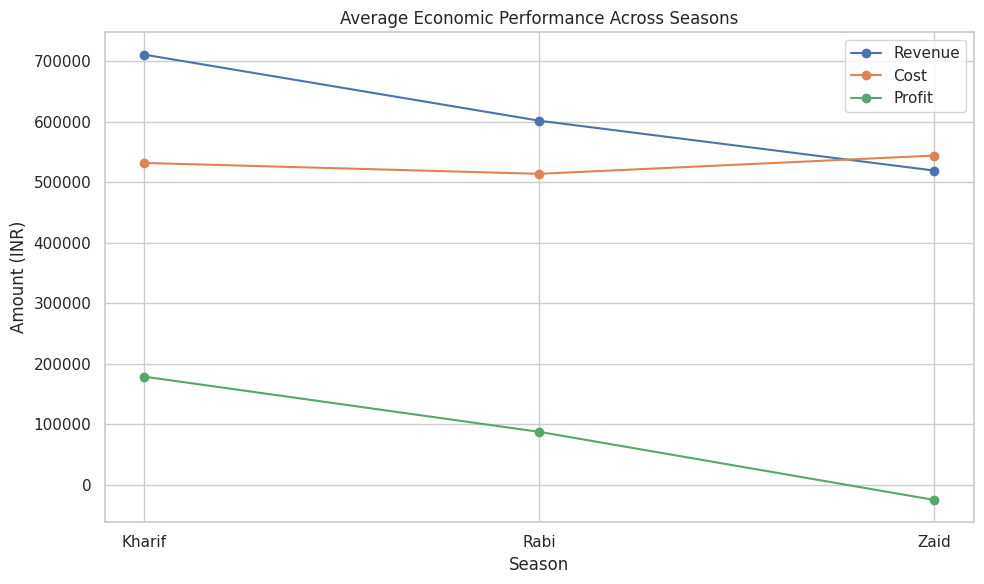

In [ ]:
economic_season = (
    df.groupby("Season")[
        ["Revenue_INR", "Total_Cost_INR", "Profit_INR"]
    ]
    .mean()
)

plt.figure(figsize=(10, 6))

plt.plot(
    economic_season.index,
    economic_season["Revenue_INR"],
    marker="o",
    label="Revenue"
)

plt.plot(
    economic_season.index,
    economic_season["Total_Cost_INR"],
    marker="o",
    label="Cost"
)

plt.plot(
    economic_season.index,
    economic_season["Profit_INR"],
    marker="o",
    label="Profit"
)

plt.title("Average Economic Performance Across Seasons")
plt.xlabel("Season")
plt.ylabel("Amount (INR)")
plt.legend()

plt.tight_layout()
plt.show()

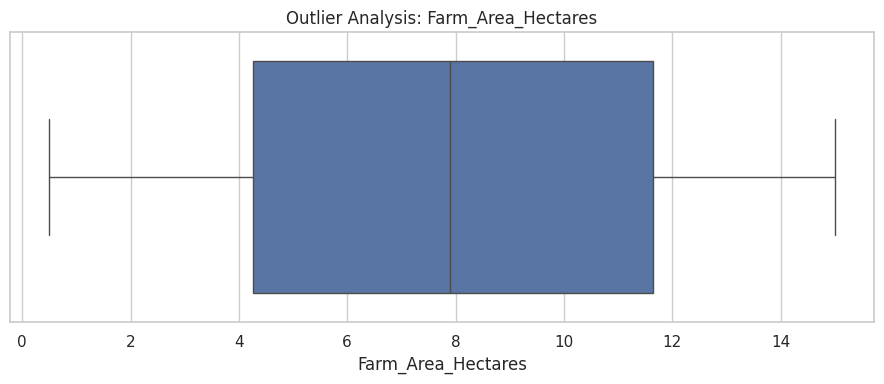

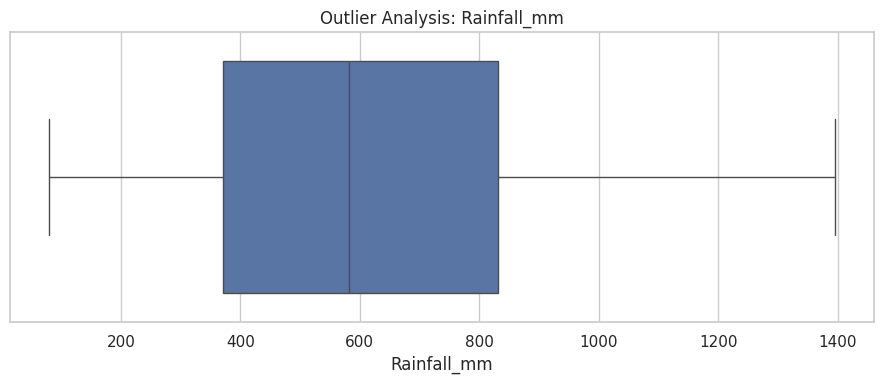

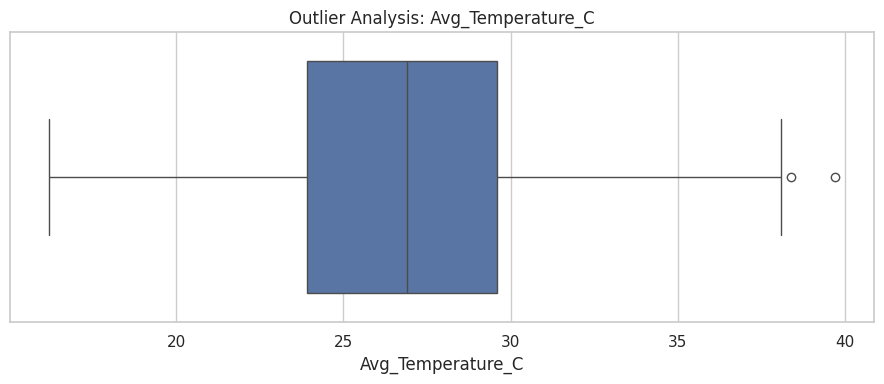

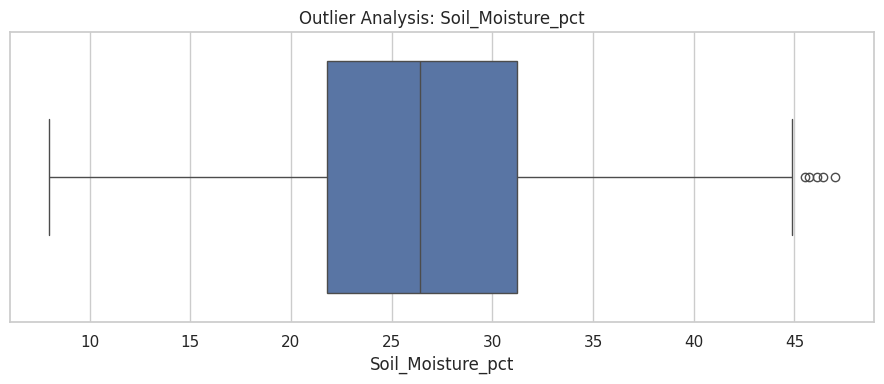

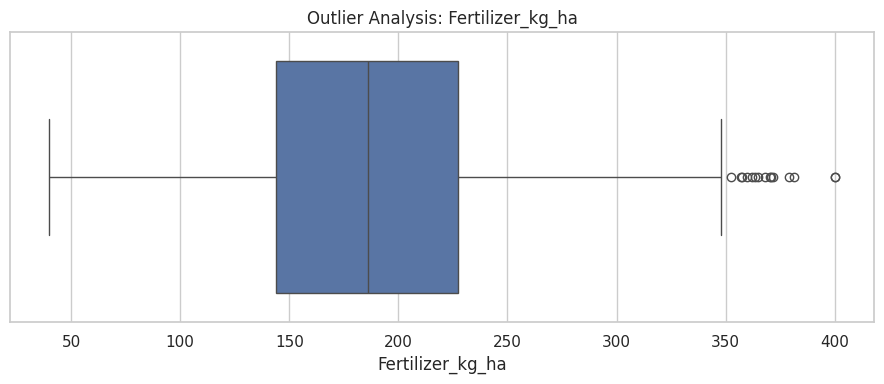

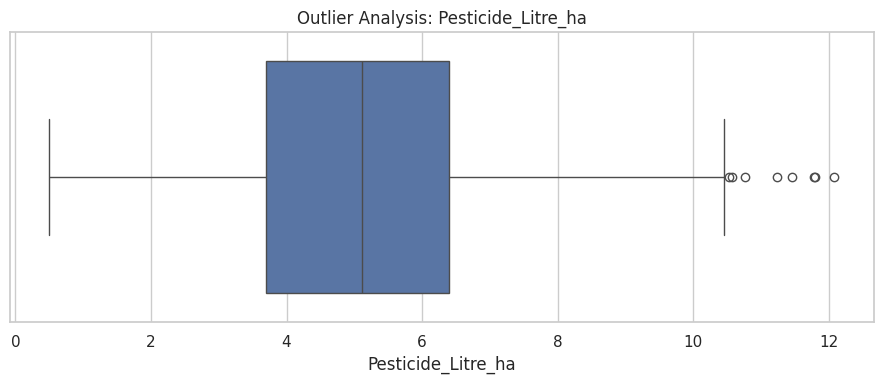

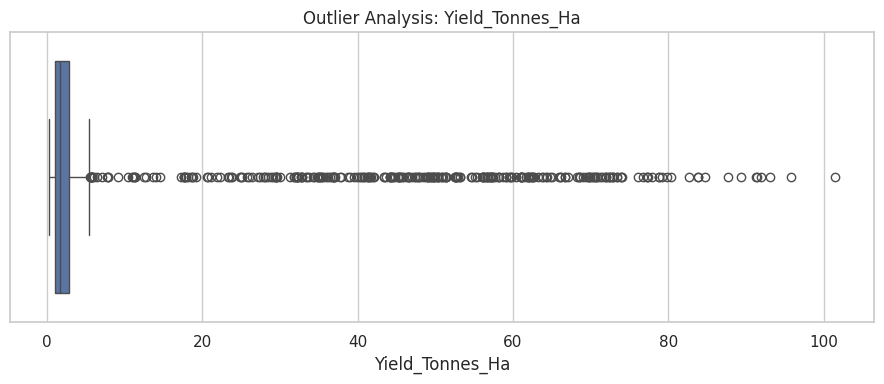

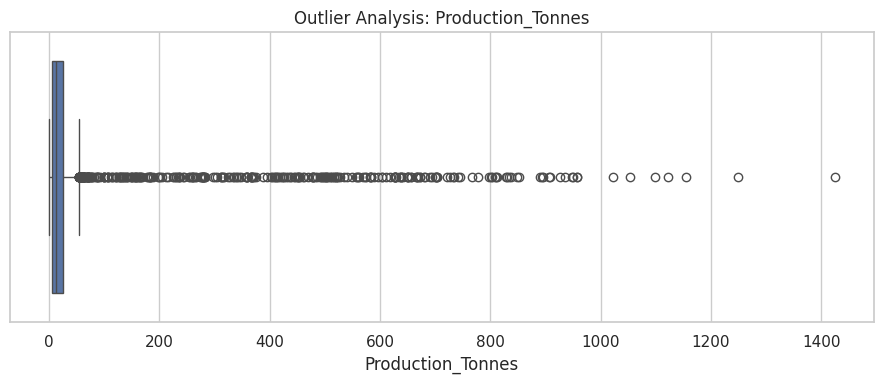

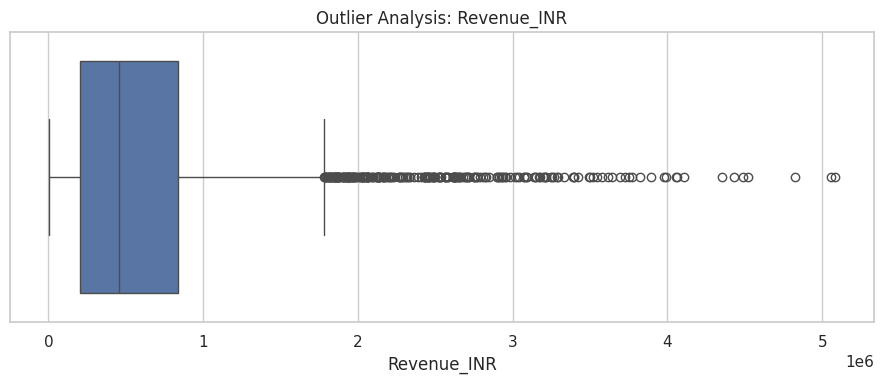

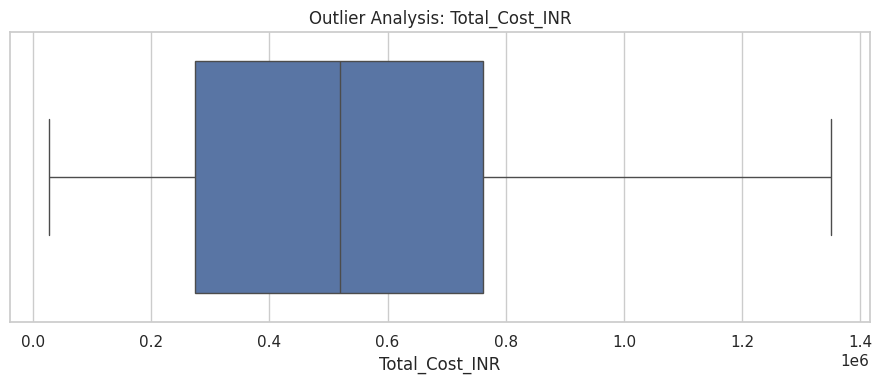

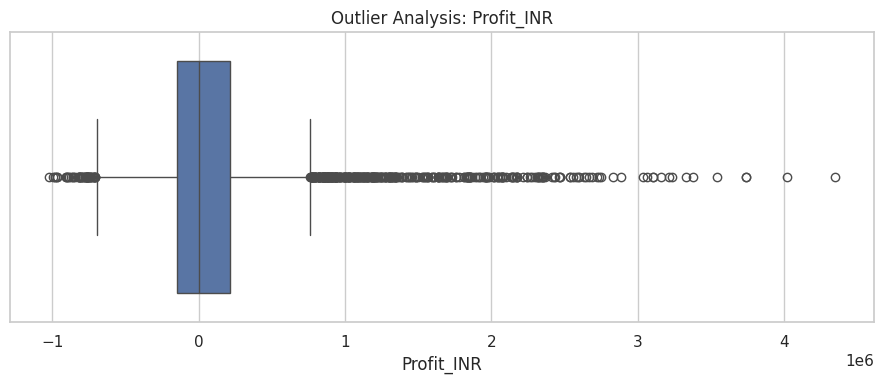

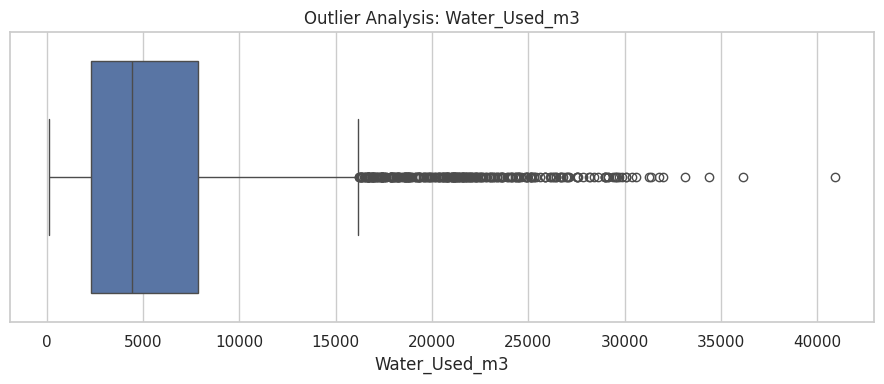

In [ ]:
numeric_columns = [
    "Farm_Area_Hectares",
    "Rainfall_mm",
    "Avg_Temperature_C",
    "Soil_Moisture_pct",
    "Fertilizer_kg_ha",
    "Pesticide_Litre_ha",
    "Yield_Tonnes_Ha",
    "Production_Tonnes",
    "Revenue_INR",
    "Total_Cost_INR",
    "Profit_INR",
    "Water_Used_m3"
]

for column in numeric_columns:

    plt.figure(figsize=(9, 4))

    sns.boxplot(
        x=df[column]
    )

    plt.title(f"Outlier Analysis: {column}")
    plt.xlabel(column)

    plt.tight_layout()
    plt.show()

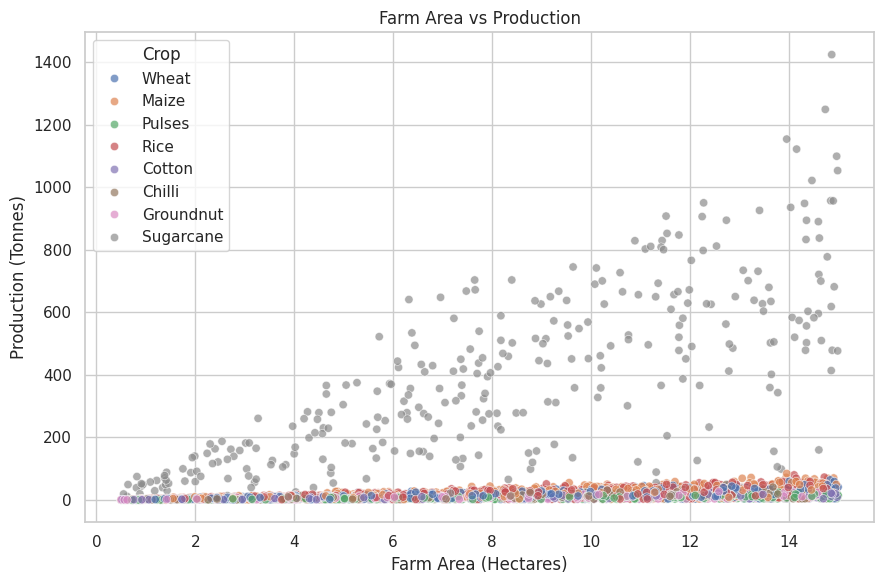

In [ ]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="Farm_Area_Hectares",
    y="Production_Tonnes",
    hue="Crop",
    alpha=0.7
)

plt.title("Farm Area vs Production")
plt.xlabel("Farm Area (Hectares)")
plt.ylabel("Production (Tonnes)")

plt.tight_layout()
plt.show()

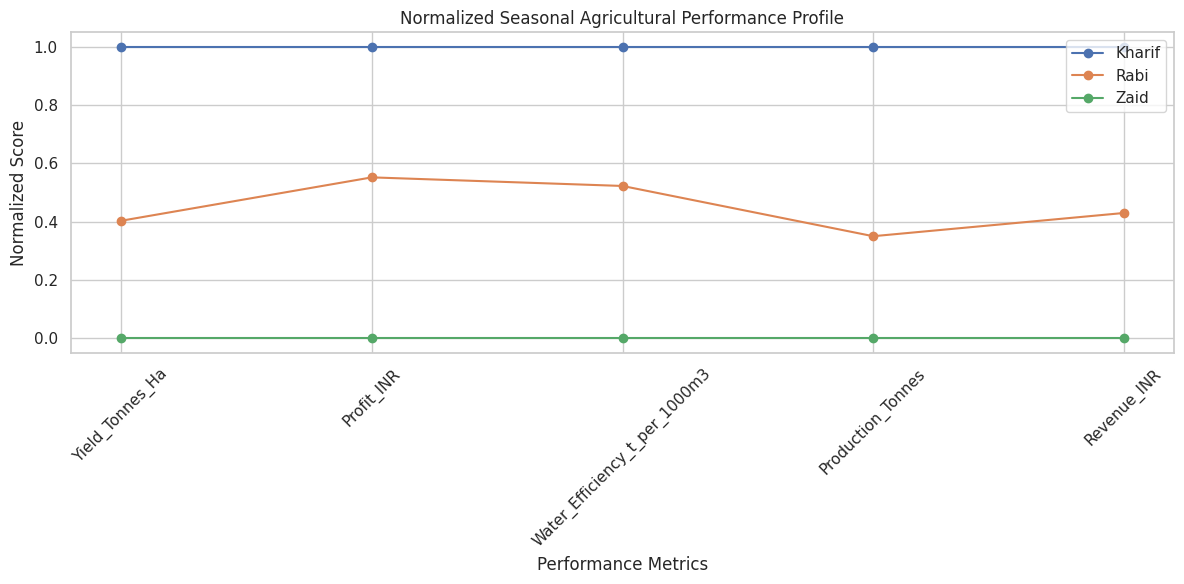

In [ ]:
season_metrics = df.groupby("Season").agg({
    "Yield_Tonnes_Ha": "mean",
    "Profit_INR": "mean",
    "Water_Efficiency_t_per_1000m3": "mean",
    "Production_Tonnes": "mean",
    "Revenue_INR": "mean"
})

# Normalize metrics so they can be compared on the same scale

scaler = MinMaxScaler()

normalized = pd.DataFrame(
    scaler.fit_transform(season_metrics),
    index=season_metrics.index,
    columns=season_metrics.columns
)

plt.figure(figsize=(12, 6))

for season in normalized.index:
    plt.plot(
        normalized.columns,
        normalized.loc[season],
        marker="o",
        label=season
    )

plt.title("Normalized Seasonal Agricultural Performance Profile")
plt.xlabel("Performance Metrics")
plt.ylabel("Normalized Score")
plt.xticks(rotation=45)
plt.legend()

plt.tight_layout()
plt.show()

## 23. Correlation Analysis

Correlation identifies linear associations; it does not prove causation.

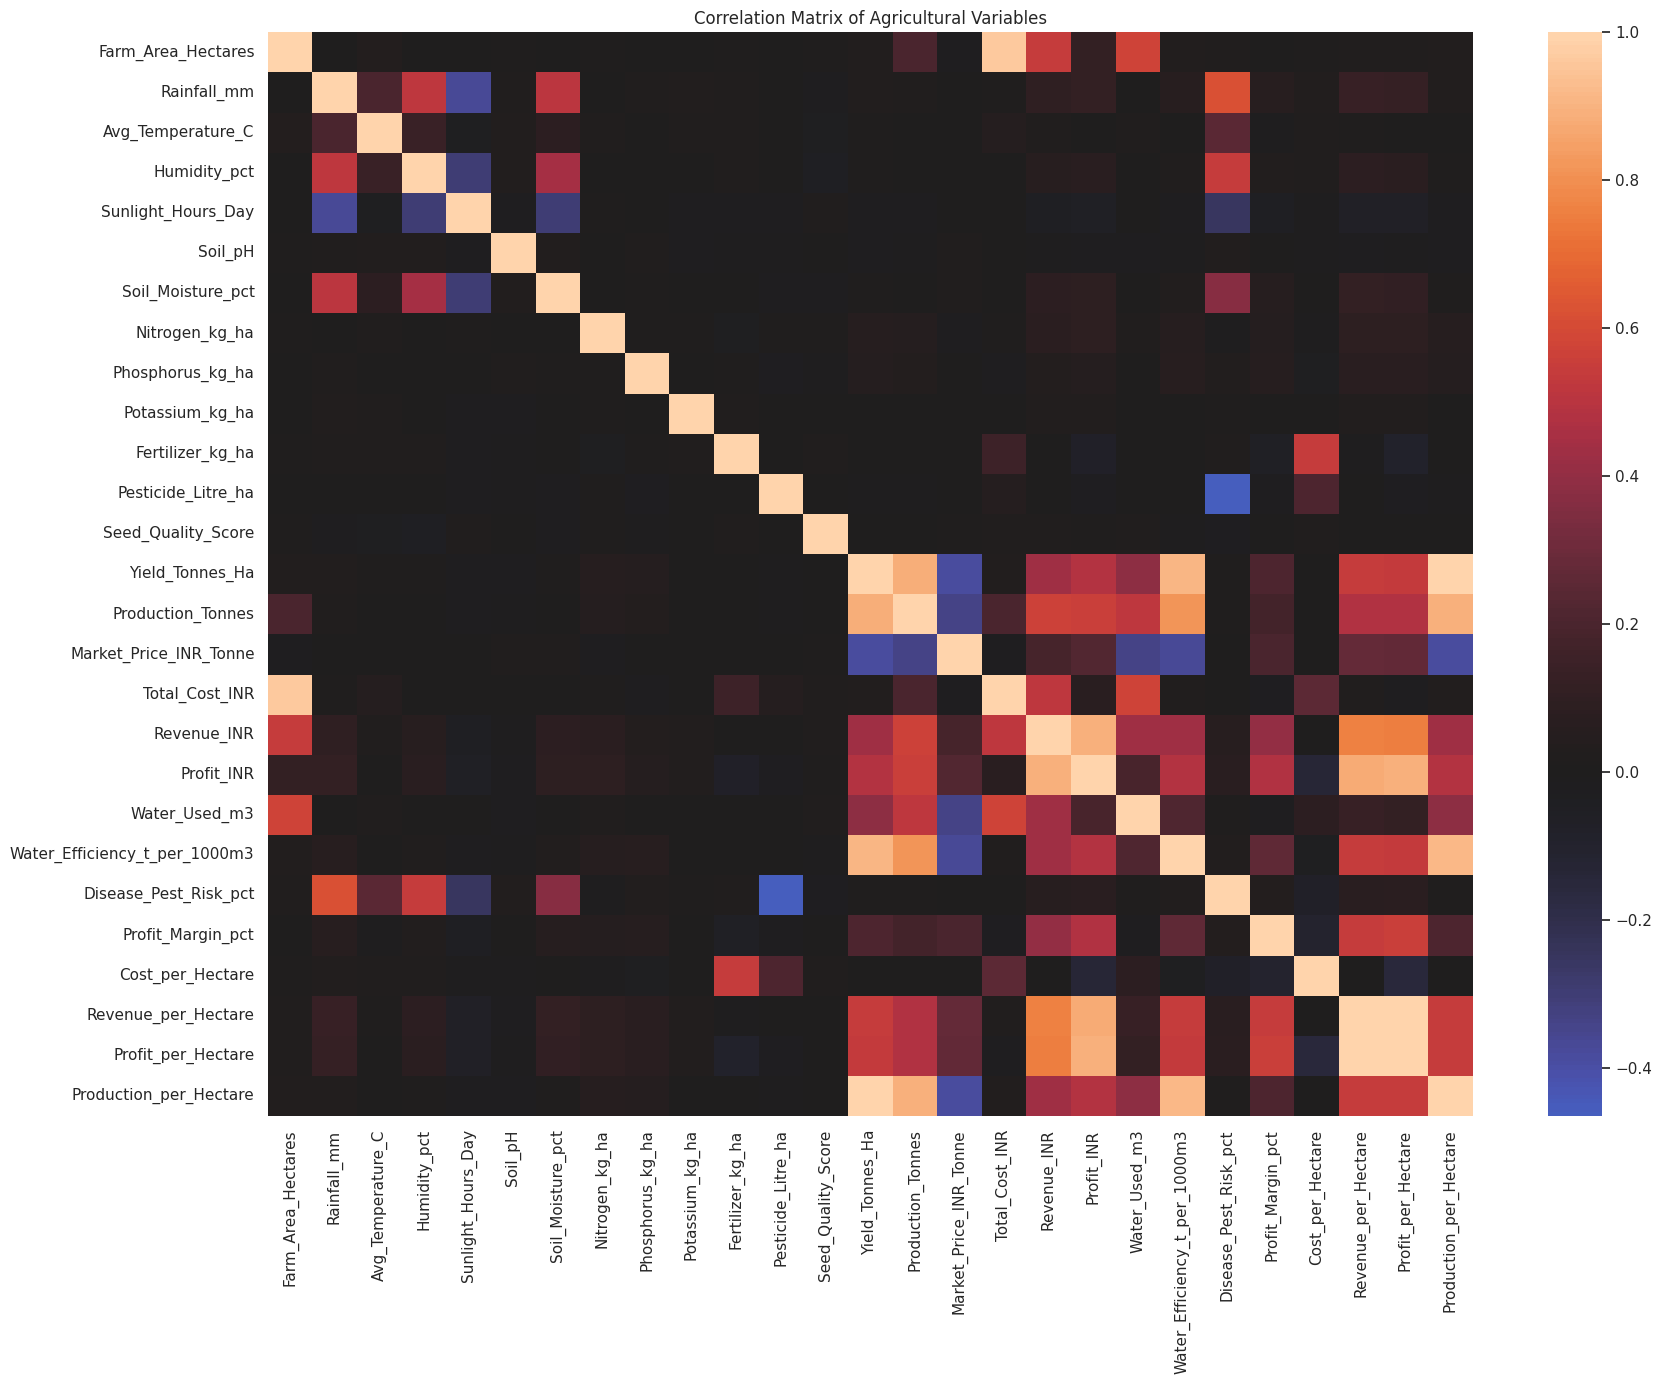

,Correlation with Yield
Yield_Tonnes_Ha,1.00
Production_per_Hectare,1.00
Water_Efficiency_t_per_1000m3,0.91
Production_Tonnes,0.88
Revenue_per_Hectare,0.54
Profit_per_Hectare,0.54
Profit_INR,0.49
Revenue_INR,0.43
Water_Used_m3,0.39
Profit_Margin_pct,0.20


,Correlation with Profit
Profit_INR,1.00
Revenue_INR,0.89
Profit_per_Hectare,0.89
Revenue_per_Hectare,0.88
Production_Tonnes,0.55
Production_per_Hectare,0.49
Water_Efficiency_t_per_1000m3,0.49
Yield_Tonnes_Ha,0.49
Profit_Margin_pct,0.48
Market_Price_INR_Tonne,0.23


In [ ]:
numeric_columns = df.select_dtypes(include=np.number).columns.tolist()
correlation_matrix = df[numeric_columns].corr()

plt.figure(figsize=(18,14))
sns.heatmap(correlation_matrix, center=0)
plt.title("Correlation Matrix of Agricultural Variables")
plt.tight_layout()
plt.show()

yield_correlations = correlation_matrix["Yield_Tonnes_Ha"].sort_values(ascending=False)
profit_correlations = correlation_matrix["Profit_INR"].sort_values(ascending=False)

display(yield_correlations.to_frame("Correlation with Yield"))
display(profit_correlations.to_frame("Correlation with Profit"))

## 24. Important Relationship Visualizations

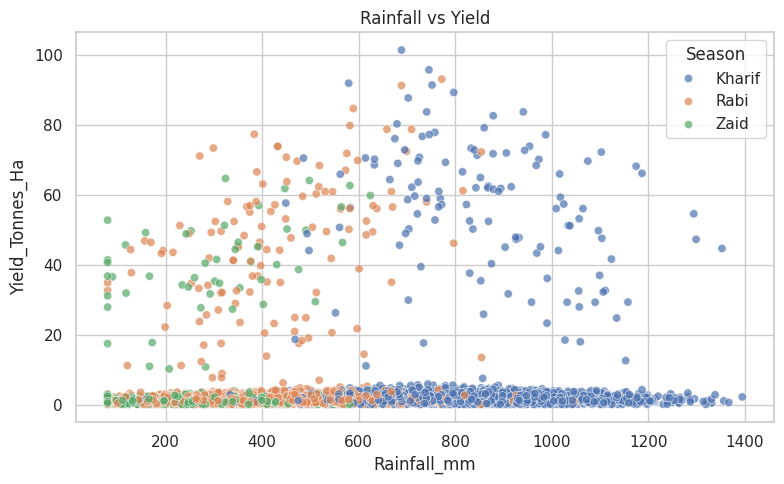

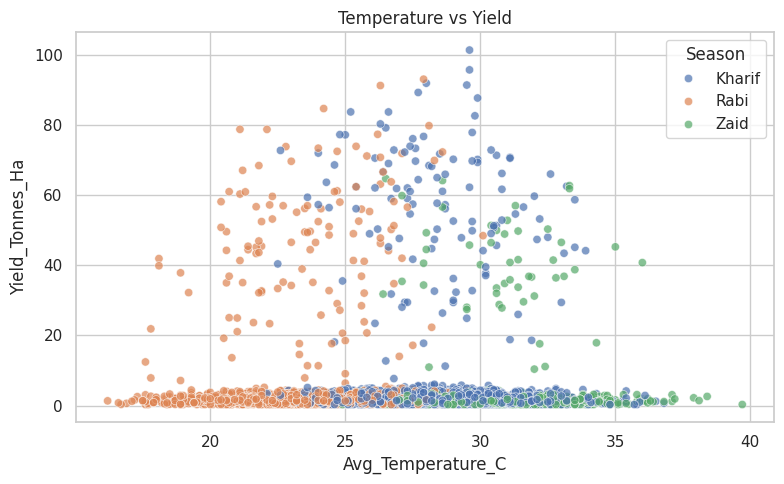

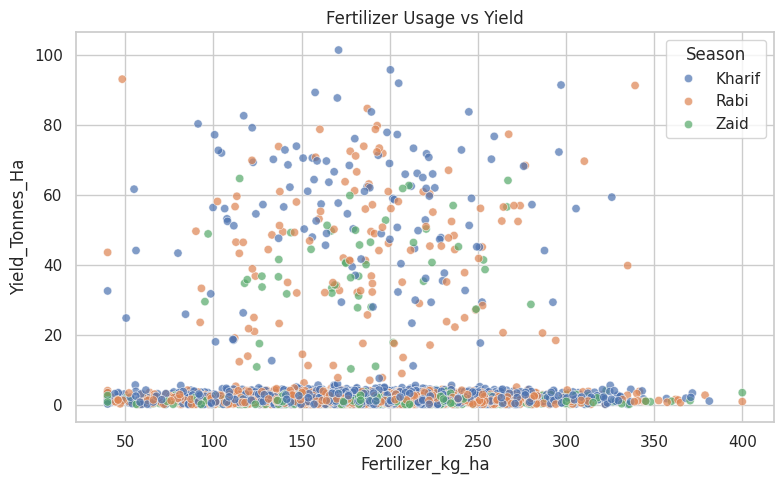

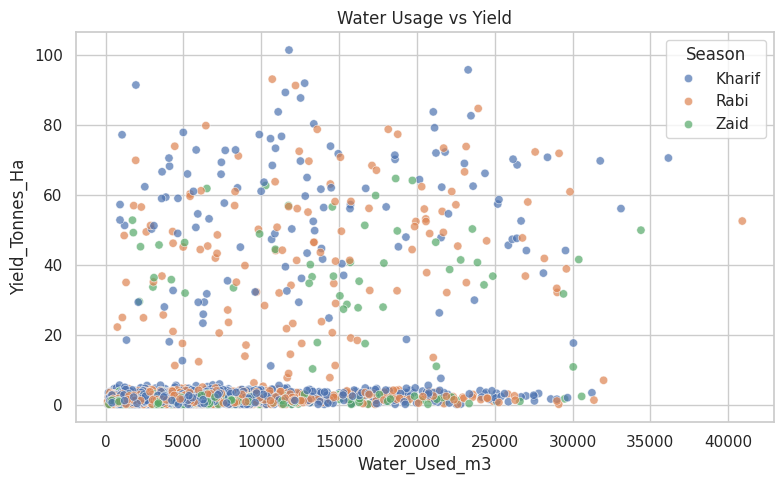

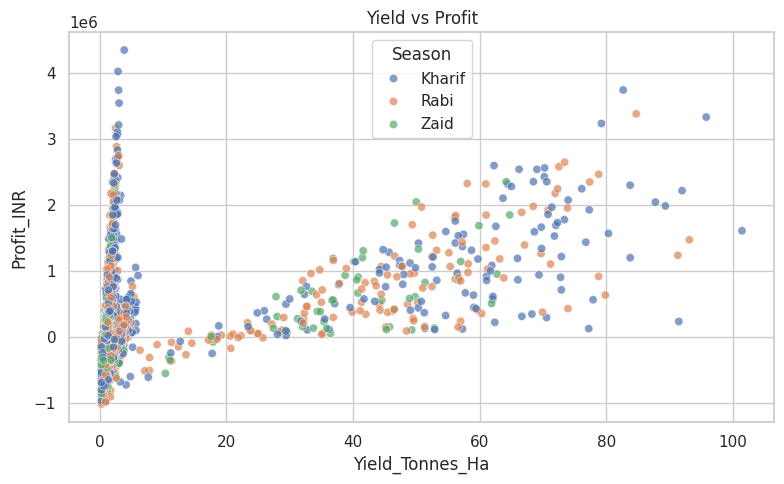

In [ ]:
relationship_pairs = [
    ("Rainfall_mm","Yield_Tonnes_Ha","Rainfall vs Yield"),
    ("Avg_Temperature_C","Yield_Tonnes_Ha","Temperature vs Yield"),
    ("Fertilizer_kg_ha","Yield_Tonnes_Ha","Fertilizer Usage vs Yield"),
    ("Water_Used_m3","Yield_Tonnes_Ha","Water Usage vs Yield"),
    ("Yield_Tonnes_Ha","Profit_INR","Yield vs Profit")
]

for x_col, y_col, title in relationship_pairs:
    plt.figure(figsize=(8,5))
    sns.scatterplot(data=df, x=x_col, y=y_col, hue="Season", alpha=0.7)
    plt.title(title)
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.tight_layout()
    plt.show()

## 25. Statistical Testing — Seasonal Yield

**H₀:** Mean yield is equal across seasons.

**H₁:** At least one season has a different mean yield.

A p-value below 0.05 is treated as statistically significant.

In [ ]:
season_groups = [g["Yield_Tonnes_Ha"].dropna().values for _, g in df.groupby("Season")]
season_names = list(df.groupby("Season").groups.keys())

f_stat_yield, p_value_yield = stats.f_oneway(*season_groups)

print("Seasons:", season_names)
print("F-statistic:", round(f_stat_yield,4))
print("p-value:", round(p_value_yield,6))

if p_value_yield < 0.05:
    print("Conclusion: Reject H0 — average yield differs significantly across seasons.")
else:
    print("Conclusion: Fail to reject H0 — evidence is insufficient to conclude that average yield differs across seasons.")

Seasons: ['Kharif', 'Rabi', 'Zaid']
F-statistic: 1.5439
p-value: 0.213678
Conclusion: Fail to reject H0 — evidence is insufficient to conclude that average yield differs across seasons.


## 26. Statistical Testing — Seasonal Profit

In [ ]:
profit_groups = [g["Profit_INR"].dropna().values for _, g in df.groupby("Season")]

f_stat_profit, p_value_profit = stats.f_oneway(*profit_groups)

print("F-statistic:", round(f_stat_profit,4))
print("p-value:", round(p_value_profit,6))

if p_value_profit < 0.05:
    print("Conclusion: Reject H0 — average profit differs significantly across seasons.")
else:
    print("Conclusion: Fail to reject H0 — evidence is insufficient to conclude that average profit differs across seasons.")

F-statistic: 34.2918
p-value: 0.0
Conclusion: Reject H0 — average profit differs significantly across seasons.


## 27. Outlier and Unusual Pattern Analysis

The IQR method identifies unusually low or high observations. Outliers are investigated rather than automatically removed.

In [ ]:
def iqr_outliers(data, column):
    q1 = data[column].quantile(0.25)
    q3 = data[column].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    mask = (data[column] < lower) | (data[column] > upper)
    return data[mask], lower, upper

yield_outliers, yield_lower, yield_upper = iqr_outliers(df, "Yield_Tonnes_Ha")
profit_outliers, profit_lower, profit_upper = iqr_outliers(df, "Profit_INR")

print("Yield lower bound:", round(yield_lower,2))
print("Yield upper bound:", round(yield_upper,2))
print("Yield outliers:", len(yield_outliers))

print("\nProfit lower bound:", round(profit_lower,2))
print("Profit upper bound:", round(profit_upper,2))
print("Profit outliers:", len(profit_outliers))

Yield lower bound: -1.62
Yield upper bound: 5.5
Yield outliers: 302

Profit lower bound: -696111.0
Profit upper bound: 763567.0
Profit outliers: 404


In [ ]:
outlier_columns = [
    c for c in ["Farm_ID","State","District","Crop","Season",
                "Yield_Tonnes_Ha","Production_Tonnes","Profit_INR"]
    if c in df.columns
]

display(
    yield_outliers[outlier_columns]
    .sort_values("Yield_Tonnes_Ha", ascending=False)
    .head(20)
)

,Farm_ID,State,District,Crop,Season,Yield_Tonnes_Ha,Production_Tonnes,Profit_INR
1715,SF11716,Gujarat,Indore,Sugarcane,Kharif,101.44,641.10,1608291
3423,SF13424,Andhra Pradesh,Indore,Sugarcane,Kharif,95.79,"1,424.40",3330582
3525,SF13526,Andhra Pradesh,Erode,Sugarcane,Rabi,93.13,648.18,1471529
1464,SF11465,Gujarat,Nashik,Sugarcane,Kharif,91.98,703.65,2216708
3523,SF13524,Karnataka,Nashik,Sugarcane,Kharif,91.46,75.00,234320
2782,SF12783,Gujarat,Nalgonda,Sugarcane,Rabi,91.32,522.35,1236801
644,SF10645,Andhra Pradesh,Ludhiana,Sugarcane,Kharif,89.34,668.26,1984818
2847,SF12848,Telangana,Warangal,Sugarcane,Kharif,87.76,672.24,2041678
357,SF10358,Punjab,Warangal,Sugarcane,Rabi,84.75,"1,249.21",3378879
1178,SF11179,Karnataka,Nalgonda,Sugarcane,Kharif,83.79,534.58,1200815


## 28. Season × Crop Consistency

In [ ]:
best_season_by_crop_yield = (
    df.groupby(["Crop","Season"])["Yield_Tonnes_Ha"]
      .mean().reset_index()
      .sort_values(["Crop","Yield_Tonnes_Ha"], ascending=[True,False])
      .groupby("Crop").head(1)
)
display(best_season_by_crop_yield)

best_season_by_crop_profit = (
    df.groupby(["Crop","Season"])["Profit_INR"]
      .mean().reset_index()
      .sort_values(["Crop","Profit_INR"], ascending=[True,False])
      .groupby("Crop").head(1)
)
display(best_season_by_crop_profit)

,Crop,Season,Yield_Tonnes_Ha
0,Chilli,Kharif,1.73
3,Cotton,Kharif,1.37
6,Groundnut,Kharif,1.48
9,Maize,Kharif,2.97
12,Pulses,Kharif,1.04
15,Rice,Kharif,2.70
18,Sugarcane,Kharif,53.46
21,Wheat,Kharif,2.25


,Crop,Season,Profit_INR
0,Chilli,Kharif,"954,380.42"
3,Cotton,Kharif,"216,999.55"
6,Groundnut,Kharif,"108,265.44"
9,Maize,Kharif,"-39,332.67"
12,Pulses,Kharif,"43,338.90"
15,Rice,Kharif,"-64,903.40"
18,Sugarcane,Kharif,"1,000,790.81"
21,Wheat,Kharif,"-105,871.87"


## 29. Composite Agricultural Performance Score

As an additional project-specific measure, yield, profit and water efficiency are normalized to 0–1 and combined:
- 40% yield
- 40% profit
- 20% water efficiency

This is a custom analytical score, not a standard agricultural index.

In [ ]:
score_variables = ["Yield_Tonnes_Ha","Profit_INR","Water_Efficiency_t_per_1000m3"]

scaler = MinMaxScaler()
scores = scaler.fit_transform(df[score_variables])

df["Yield_Score"] = scores[:,0]
df["Profit_Score"] = scores[:,1]
df["Water_Efficiency_Score"] = scores[:,2]

df["Performance_Score"] = (
    0.40*df["Yield_Score"] +
    0.40*df["Profit_Score"] +
    0.20*df["Water_Efficiency_Score"]
)

season_score = df.groupby("Season")["Performance_Score"].mean().sort_values(ascending=False)
display(season_score.round(4).to_frame("Average Performance Score"))

,Average Performance Score
Season,
Kharif,0.12
Rabi,0.11
Zaid,0.10


## 30. Final Seasonal Performance Summary

In [ ]:
final_season_summary = df.groupby("Season").agg(
    Records=("Season","size"),
    Avg_Yield=("Yield_Tonnes_Ha","mean"),
    Avg_Production=("Production_Tonnes","mean"),
    Avg_Revenue=("Revenue_INR","mean"),
    Avg_Cost=("Total_Cost_INR","mean"),
    Avg_Profit=("Profit_INR","mean"),
    Avg_Water_Used=("Water_Used_m3","mean"),
    Avg_Water_Efficiency=("Water_Efficiency_t_per_1000m3","mean"),
    Avg_Disease_Risk=("Disease_Pest_Risk_pct","mean"),
    Avg_Performance_Score=("Performance_Score","mean")
).round(2)

display(final_season_summary)

,Records,Avg_Yield,Avg_Production,Avg_Revenue,Avg_Cost,Avg_Profit,Avg_Water_Used,Avg_Water_Efficiency,Avg_Disease_Risk,Avg_Performance_Score
Season,,,,,,,,,,
Kharif,1779,5.63,46.31,"710,719.06","531,804.41","178,914.65","6,102.20",5.89,54.47,0.12
Rabi,1627,5.04,41.49,"601,526.05","513,836.58","87,689.47","5,846.99",5.19,40.48,0.11
Zaid,594,4.64,38.89,"519,171.90","543,976.73","-24,804.82","6,419.89",4.41,38.22,0.10


## 31. Automatic Key Findings

In [ ]:
best_yield_season = df.groupby("Season")["Yield_Tonnes_Ha"].mean().idxmax()
best_profit_season = df.groupby("Season")["Profit_INR"].mean().idxmax()
best_water_season = df.groupby("Season")["Water_Efficiency_t_per_1000m3"].mean().idxmax()
lowest_risk_season = df.groupby("Season")["Disease_Pest_Risk_pct"].mean().idxmin()
best_score_season = df.groupby("Season")["Performance_Score"].mean().idxmax()

best_crop_profit = df.groupby("Crop")["Profit_INR"].mean().idxmax()
best_crop_yield = df.groupby("Crop")["Yield_Tonnes_Ha"].mean().idxmax()
best_state_profit = df.groupby("State")["Profit_INR"].mean().idxmax()
best_irrigation_yield = df.groupby("Irrigation_Method")["Yield_Tonnes_Ha"].mean().idxmax()
best_irrigation_water = df.groupby("Irrigation_Method")["Water_Efficiency_t_per_1000m3"].mean().idxmax()

print("KEY FINDINGS")
print("="*70)
print(f"• Highest average yield season: {best_yield_season}")
print(f"• Highest average profit season: {best_profit_season}")
print(f"• Highest average water-efficiency season: {best_water_season}")
print(f"• Lowest average disease/pest-risk season: {lowest_risk_season}")
print(f"• Highest composite performance-score season: {best_score_season}")
print(f"• Highest average-profit crop: {best_crop_profit}")
print(f"• Highest average-yield crop: {best_crop_yield}")
print(f"• Highest average-profit state: {best_state_profit}")
print(f"• Irrigation method with highest average yield: {best_irrigation_yield}")
print(f"• Irrigation method with highest average water efficiency: {best_irrigation_water}")

print("\nSTATISTICAL EVIDENCE")
print("="*70)
print(f"Yield ANOVA p-value: {p_value_yield:.6g}")
print(f"Profit ANOVA p-value: {p_value_profit:.6g}")

print("\nOUTLIERS")
print("="*70)
print(f"Yield outliers detected: {len(yield_outliers):,}")
print(f"Profit outliers detected: {len(profit_outliers):,}")

KEY FINDINGS
• Highest average yield season: Kharif
• Highest average profit season: Kharif
• Highest average water-efficiency season: Kharif
• Lowest average disease/pest-risk season: Zaid
• Highest composite performance-score season: Kharif
• Highest average-profit crop: Sugarcane
• Highest average-yield crop: Sugarcane
• Highest average-profit state: Punjab
• Irrigation method with highest average yield: Drip
• Irrigation method with highest average water efficiency: Rainfed

STATISTICAL EVIDENCE
Yield ANOVA p-value: 0.213678
Profit ANOVA p-value: 1.71242e-15

OUTLIERS
Yield outliers detected: 302
Profit outliers detected: 404


## 32. Evidence-Based Recommendations

In [ ]:
print("RECOMMENDATIONS")
print("="*70)

print(
    f"1. Seasonal planning: prioritize closer evaluation of {best_score_season}, "
    "which has the highest composite performance score under this project's weighting."
)

print(
    f"2. Yield planning: investigate conditions associated with {best_yield_season}, "
    "the season with the highest average yield, and check whether the pattern is consistent across crops and states."
)

print(
    f"3. Economic planning: examine practices and crop mix associated with {best_profit_season}, "
    "which has the highest average profit."
)

print(
    f"4. Water management: compare practices used in {best_water_season} and with "
    f"{best_irrigation_water}, the irrigation method with the highest average water efficiency."
)

print(
    f"5. Crop strategy: evaluate {best_crop_profit} for economic performance and "
    f"{best_crop_yield} for yield performance, while checking seasonal consistency."
)

print(
    f"6. Regional planning: investigate why {best_state_profit} has the highest average profit "
    "and whether this is associated with crop mix, season, resource usage or environmental conditions."
)

print(
    f"7. Risk management: monitor conditions associated with {lowest_risk_season} and "
    "compare them with higher-risk seasons to identify potentially useful preventive practices."
)

if p_value_yield < 0.05:
    print("8. Statistical evidence: seasonal yield differences are statistically significant at the 5% level.")
else:
    print("8. Statistical evidence: yield differences are not statistically significant at the 5% level; interpret mean differences cautiously.")

if p_value_profit < 0.05:
    print("9. Economic evidence: seasonal profit differences are statistically significant at the 5% level.")
else:
    print("9. Economic evidence: profit differences are not statistically significant at the 5% level; interpret mean differences cautiously.")

RECOMMENDATIONS
1. Seasonal planning: prioritize closer evaluation of Kharif, which has the highest composite performance score under this project's weighting.
2. Yield planning: investigate conditions associated with Kharif, the season with the highest average yield, and check whether the pattern is consistent across crops and states.
3. Economic planning: examine practices and crop mix associated with Kharif, which has the highest average profit.
4. Water management: compare practices used in Kharif and with Rainfed, the irrigation method with the highest average water efficiency.
5. Crop strategy: evaluate Sugarcane for economic performance and Sugarcane for yield performance, while checking seasonal consistency.
6. Regional planning: investigate why Punjab has the highest average profit and whether this is associated with crop mix, season, resource usage or environmental conditions.
7. Risk management: monitor conditions associated with Zaid and compare them with higher-risk season

## 33. Conclusion

This project provides a structured analysis of seasonal agricultural performance. It examines seasonal differences in yield, production, resource consumption, environmental conditions, irrigation, water efficiency, disease/pest risk and economic outcomes.

The analysis combines descriptive statistics, group comparisons, visualization, correlation analysis, crop and regional comparisons, outlier detection, ANOVA-based statistical testing and a clearly labelled composite performance score.

The final interpretation should focus on evidence from the dataset. Correlations and seasonal differences identify useful patterns, but they should not automatically be interpreted as causal relationships.

The results can support better seasonal agricultural planning by helping stakeholders compare seasons, identify high-performing crops and regions, understand resource-use differences, investigate unusual observations, and focus further investigation on the strongest evidence-based patterns.

## 34. Project Coverage Checklist

| Requirement from project brief | Notebook coverage |
|---|---|
| Explore and understand dataset | Sections 4–5 |
| Clean and prepare data | Sections 6–8 |
| Examine seasonal performance | Sections 10–13 |
| Identify seasonal patterns/trends | Sections 11–13, 28–31 |
| Investigate environmental conditions | Section 14 |
| Compare resource usage | Sections 15–16 |
| Compare relevant groups | Sections 17–19, 28 |
| Identify significant/unusual patterns | Section 27 |
| Apply statistical techniques | Sections 25–26 |
| Use visualization techniques | Throughout |
| Interpret analytical findings | Sections 31–33 |
| Develop evidence-based insights | Section 31 |
| Provide recommendations | Section 32 |
| Support seasonal agricultural planning | Sections 32–33 |
| Document complete analysis in Jupyter Notebook | Entire notebook |